# EDA of the WWF LPD 2024 Data - Direction B: Population Forecasting

---
# **1 - INTRO**

### 1.1 - OBJECTIVE

Exploratory Data Analysis for population forecasting based on the Living Planet Database 2024

### 1.2 - TABLE OF CONTENTS

**Approach:**
1. Dataset Overview & Structure
2. Data Quality Assessment
3. Species & Geographic Distribution
4. Temporal Analysis (Time series coverage)
5. Population Trends & Patterns
6. Sample Time Series Analysis
7. Key Features & Dimensions for Forecasting
8. Conclusions & Next Steps

---
# **2 - SETUP**

### 2.1 - IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### 2.2 - DATA LOADING

In [ ]:
df = pd.read_csv('../data/raw/WWF_LPD_2024_public.csv')

---
# **3 - DATASET GENERALS**

### 3.1 - MAIN FEATURES

In [9]:
print(f"\nDataset Shape:\t {df.shape}")
print(f"Records:\t  {df.shape[0]}")
print(f"Features/columns: {df.shape[1]}")

# Display column information
print("\nColumn Names and Data Types:")
print("-" * 80)
print(df.dtypes.value_counts())

print("\nFirst few columns:")
print(df.columns[:15].tolist())


Dataset Shape:	 (35996, 103)
Records:	  35996
Features/columns: 103

Column Names and Data Types:
--------------------------------------------------------------------------------
float64    74
object     24
int64       5
Name: count, dtype: int64

First few columns:
['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries']


### 3.2 - HEAD

In [10]:
print("\nFirst few rows:")
df.head()


First few rows:


,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,...,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of ...",Aves,Gruiformes,Gruidae,Balearica,regulorum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush...",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G,...",Aves,Falconiformes,Falconidae,Falco,punctatus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


### 3.3 - DESCRIPTION & INFO

In [14]:
# General statistics for numeric columns
df.describe()

,ID,Replicate,Included in LPR2024,Latitude,Longitude,Specific_location,1950,1951,1952,1953,...,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
count,3.599600e+04,35996.000000,35996.000000,35996.000000,35996.000000,35996.000000,2.650000e+02,2.450000e+02,2.900000e+02,2.850000e+02,...,1.081900e+04,1.064600e+04,8.483000e+03,8.355000e+03,6.989000e+03,7.158000e+03,5.754000e+03,4.723000e+03,35996.000000,0.0
mean,6.459045e+04,0.164991,0.823036,8.608007,21.000447,0.386599,9.441820e+12,1.004931e+13,8.351971e+12,8.287969e+12,...,6.476127e+10,7.149301e+10,9.804856e+10,1.079763e+11,1.735201e+09,7.181254e+03,8.459899e+03,8.185544e+03,0.989082,NaN
std,8.889885e+04,0.371177,0.381644,37.037693,98.388333,0.486977,1.535733e+14,1.571631e+14,1.421069e+14,1.397940e+14,...,6.321280e+12,6.972580e+12,8.646349e+12,9.488710e+12,1.355151e+11,1.651328e+05,2.071889e+05,2.261049e+05,0.103918,NaN
min,1.000000e+00,0.000000,0.000000,-78.193822,-180.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN
25%,9.743750e+03,0.000000,1.000000,-26.473889,-64.873712,0.000000,8.000000e+00,7.200000e+00,1.100000e+01,8.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,NaN
50%,2.192350e+04,0.000000,1.000000,-0.608193,10.500000,0.000000,2.430000e+02,3.530000e+02,2.815000e+02,2.940000e+02,...,1.000000e+00,1.000000e+00,6.250000e-01,5.000000e-01,2.500000e-01,5.000000e-01,2.500000e-01,0.000000e+00,1.000000,NaN
75%,1.223572e+05,0.000000,1.000000,46.231220,132.024800,1.000000,2.071800e+04,3.212100e+04,2.459050e+04,2.782500e+04,...,1.490000e+01,1.560000e+01,1.500000e+01,1.500000e+01,1.075000e+01,1.400000e+01,8.000000e+00,8.000000e+00,1.000000,NaN
max,1.000007e+06,1.000000,1.000000,81.000000,180.000000,1.000000,2.500000e+15,2.460000e+15,2.420000e+15,2.360000e+15,...,6.570000e+14,7.190000e+14,7.960000e+14,8.670000e+14,1.130000e+13,9.747000e+06,1.204100e+07,1.280200e+07,1.000000,NaN


In [15]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35996 entries, 0 to 35995
Columns: 103 entries, ID to Unnamed: 102
dtypes: float64(74), int64(5), object(24)
memory usage: 28.3+ MB


### 3.4 - COLUMN DETAILS

In [17]:
# Identify year columns (population data)
year_cols = [col for col in df.columns if col.isdigit()]
print(f"\nYear Columns Available: {sorted(year_cols)}")
print(f"Time Range: {min(year_cols)} - {max(year_cols)}")
print(f"Number of Years: {len(year_cols)}")

# Display metadata columns
metadata_columns = [col for col in df.columns if col not in year_cols]
print(f"\nMetadata Columns ({len(metadata_columns)}):")
for col in metadata_columns:
    print(f"  - {col}")

# Print all available columns for reference
print("\nAll Columns in the Dataset:")
for col in df.columns:
    print(f"  - {col}")


Year Columns Available: ['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']
Time Range: 1950 - 2020
Number of Years: 71

Metadata Columns (32):
  - ID
  - Binomial
  - Replicate
  - Included in LPR2024
  - Citation
  - Class
  - Order
  - Family
  - Genus
  - Species
  - Subspecies
  - Common_name
  - Location
  - Country
  - All_countries
  - Region
  - IPBES_region
  - IPBES_subregion
  - Latitude
  - Longitude
  - Specific_location
  - System
  - T_realm
  - T_biome
  - FW_r

*Result summary:*

The dataset contains a mix of metadata and time-series data. Time-series data needs to be evaluated for usefullness for time-series-forecasting. Metadata needs to be evaluated for usefullness as features.

In [76]:
# "Class" value counts
print("\nAnimal Classes in the Dataset:")
print(df["Class"].value_counts())

# "System" value counts
print("\nSystems in the Dataset:")
print(df["System"].value_counts())

# "Replicate" value counts (0 = single population, 1 = multiple populations)
print("\nReplicate Status in the Dataset:")
print(df["Replicate"].value_counts())

# Included in LPR2024 value counts (1 = included, 0 = not included)
print("\nIncluded in LPR2024:")
print(df["Included in LPR2024"].value_counts())

# "Location" value counts + total number of unique locations
print(f"\nUnique Locations: {df['Location'].nunique()}")

# "Native" value counts (1 = native population, 0 = non-native population)
print("\nNative Status of Populations:")
print(df["Native"].value_counts())

# "Country" value counts + total number of unique countries
print(f"\nUnique Countries: {df['Country'].nunique()}")
print("\nCountry Value Counts:")
print(df["Country"].value_counts().head(20))  # Show top 20 countries

# Display all countries in the dataset as a list
print("\nAll Countries in the Dataset:")    
print(df["Country"].unique())


Animal Classes in the Dataset:
Class
Aves              17834
Actinopteri       10081
Mammalia           5910
Reptilia            828
Amphibia            699
Elasmobranchii      591
Myxini               28
Holocephali          12
Petromyzonti          9
Dipneusti             3
Coelacanthi           1
Name: count, dtype: int64

Systems in the Dataset:
System
Marine         16258
Terrestrial    11858
Freshwater      7880
Name: count, dtype: int64

Replicate Status in the Dataset:
Replicate
0    30057
1     5939
Name: count, dtype: int64

Included in LPR2024:
Included in LPR2024
1    29626
0     6370
Name: count, dtype: int64

Unique Locations: 7678

Native Status of Populations:
Native
1    35603
0      393
Name: count, dtype: int64

Unique Countries: 202

Country Value Counts:
Country
Australia                       11413
Canada                           6297
Brazil                           3693
United States                    2066
Spain                             870
United Kingdom 

### 3.5 - DISCLAIMER

This EDA is aout the whole dataset. If we decide to go down the route of taking into account online land animals, we would have to filter out the dataset and only keep terresterial records as follows.

In [ ]:
land_df = df[df["System"] == "Terrestrial"].copy()

print("Original shape:", df.shape)
print("Land animal shape:", land_df.shape)
print("\nAnimal classes in the land-animal dataset:")
print(land_df["Class"].value_counts())

# and potentially overwrite the original df if we want to focus only on land animals
# df = land_df.copy()

Original shape: (35996, 103)
Land animal shape: (11858, 103)

Animal classes in the land-animal dataset:
Class
Aves        6134
Mammalia    5137
Reptilia     320
Amphibia     267
Name: count, dtype: int64


---
# **4 - DATA QUALITY ASSESSMENT**

### 4.1 - MISSING VALUES


Missing Values Analysis:
--------------------------------------------------------------------------------

Top 20 Year Columns with Missing Values:
      Missing Values  Percentage
1951           35751   99.319369
1950           35731   99.263807
1953           35711   99.208245
1952           35706   99.194355
1954           35693   99.158240
1955           35671   99.097122
1957           35656   99.055451
1956           35625   98.969330
1958           35614   98.938771
1959           35569   98.813757
1960           35389   98.313702
1961           35348   98.199800
1962           35336   98.166463
1963           35305   98.080342
1964           35245   97.913657
1965           35133   97.602511
1966           35120   97.566396
1967           34956   97.110790
1968           34932   97.044116
1969           34884   96.910768

Top 20 Year Columns with Least Missing Values:
      Missing Values  Percentage
2011           23680   65.785087
2010           24241   67.343594
2012       

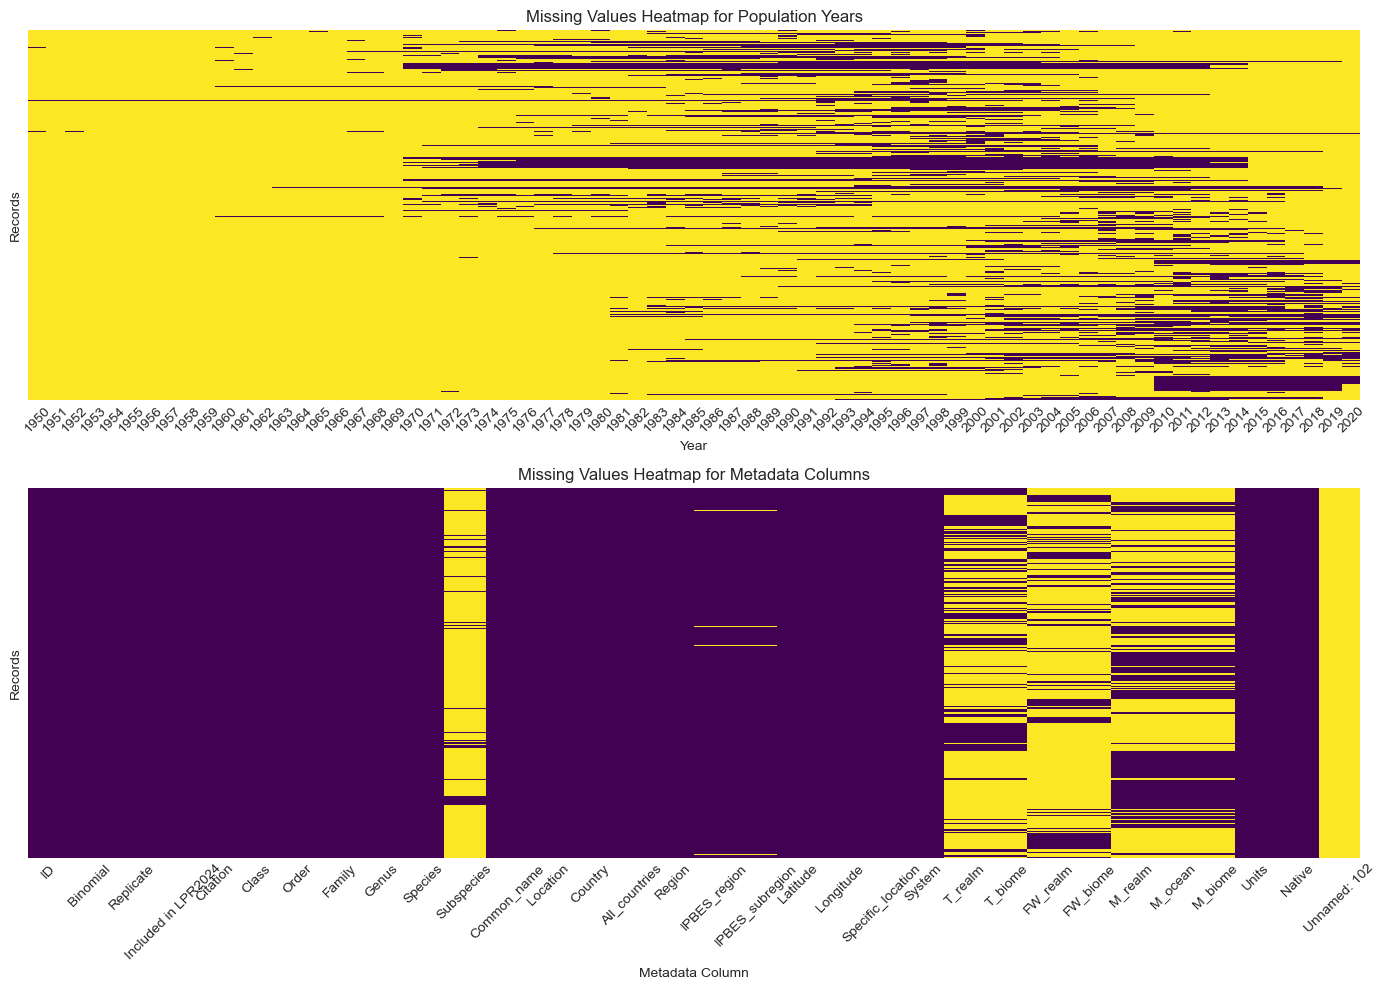

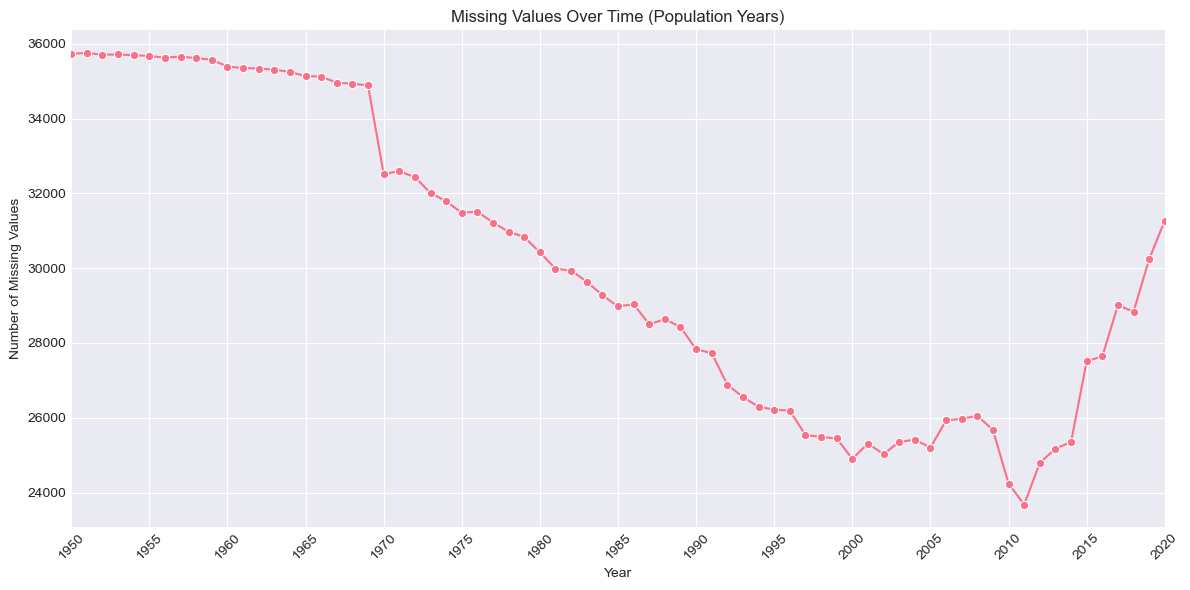

In [34]:
# Missing values analysis
print("\nMissing Values Analysis:")
print("-" * 80)

# Top 20 year columns with missing values (and percentages)
missing_years = df[year_cols].isnull().sum().sort_values(ascending=False).head(20)
missing_years_percent = (missing_years / len(df)) * 100
missing_years_df = pd.DataFrame({
    'Missing Values': missing_years,
    'Percentage': missing_years_percent
})
print("\nTop 20 Year Columns with Missing Values:")
print(missing_years_df)

# Print best 20 year with least missing values (and percentages)
least_missing_years = df[year_cols].isnull().sum().sort_values(ascending=True).head(20)
least_missing_years_percent = (least_missing_years / len(df)) * 100 
least_missing_years_df = pd.DataFrame({
    'Missing Values': least_missing_years,
    'Percentage': least_missing_years_percent
})
print("\nTop 20 Year Columns with Least Missing Values:")
print(least_missing_years_df)


# Metadata columns missing values
missing_metadata = df[metadata_columns].isnull().sum().sort_values(ascending=False)
missing_metadata_percent = (missing_metadata / len(df)) * 100
missing_metadata_df = pd.DataFrame({
    'Missing Values': missing_metadata,
    'Percentage': missing_metadata_percent
})
print("\nMetadata Columns with Missing Values:")
print(missing_metadata_df)

# Plot missingness heatmap for year columns and for metadata columns
print("\nPlotting missing values heatmaps for year columns and metadata columns - yellow is missing, purple is present:")
plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
sns.heatmap(df[year_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap for Population Years')
plt.xlabel('Year')
plt.ylabel('Records')
plt.xticks(rotation=45)
plt.subplot(2, 1, 2)
sns.heatmap(df[metadata_columns].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap for Metadata Columns')
plt.xlabel('Metadata Column')
plt.ylabel('Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Missing data over time
missing_over_time = df[year_cols].isnull().sum()
years = missing_over_time.index.astype(int)
plt.figure(figsize=(12, 6))
sns.lineplot(x=years, y=missing_over_time.values, marker='o')
plt.title('Missing Values Over Time (Population Years)')
plt.xlabel('Year')
plt.ylabel('Number of Missing Values')
tick_years = [y for y in years if y % 5 == 0]
plt.xticks(tick_years, rotation=45)
plt.xlim(years.min(), years.max())
plt.tight_layout()
plt.show()

### 4.2 - NULL VALUES ANALYSIS


0s Values Analysis in Population Years:
  1950:     24 (  0.1%)
  1951:     23 (  0.1%)
  1952:     19 (  0.1%)
  1953:     20 (  0.1%)
  1954:     19 (  0.1%)
  1955:     23 (  0.1%)
  1956:     26 (  0.1%)
  1957:     17 (  0.0%)
  1958:     23 (  0.1%)
  1959:     26 (  0.1%)
  1960:     39 (  0.1%)
  1961:     33 (  0.1%)
  1962:     24 (  0.1%)
  1963:     22 (  0.1%)
  1964:     34 (  0.1%)
  1965:     37 (  0.1%)
  1966:     34 (  0.1%)
  1967:     33 (  0.1%)
  1968:     40 (  0.1%)
  1969:     32 (  0.1%)
  1970:     77 (  0.2%)
  1971:     68 (  0.2%)
  1972:     73 (  0.2%)
  1973:     81 (  0.2%)
  1974:     73 (  0.2%)
  1975:     91 (  0.3%)
  1976:     79 (  0.2%)
  1977:     70 (  0.2%)
  1978:     76 (  0.2%)
  1979:     91 (  0.3%)
  1980:     97 (  0.3%)
  1981:    260 (  0.7%)
  1982:    292 (  0.8%)
  1983:    259 (  0.7%)
  1984:    337 (  0.9%)
  1985:    397 (  1.1%)
  1986:    294 (  0.8%)
  1987:    328 (  0.9%)
  1988:    344 (  1.0%)
  1989:    317 (  0.9%)

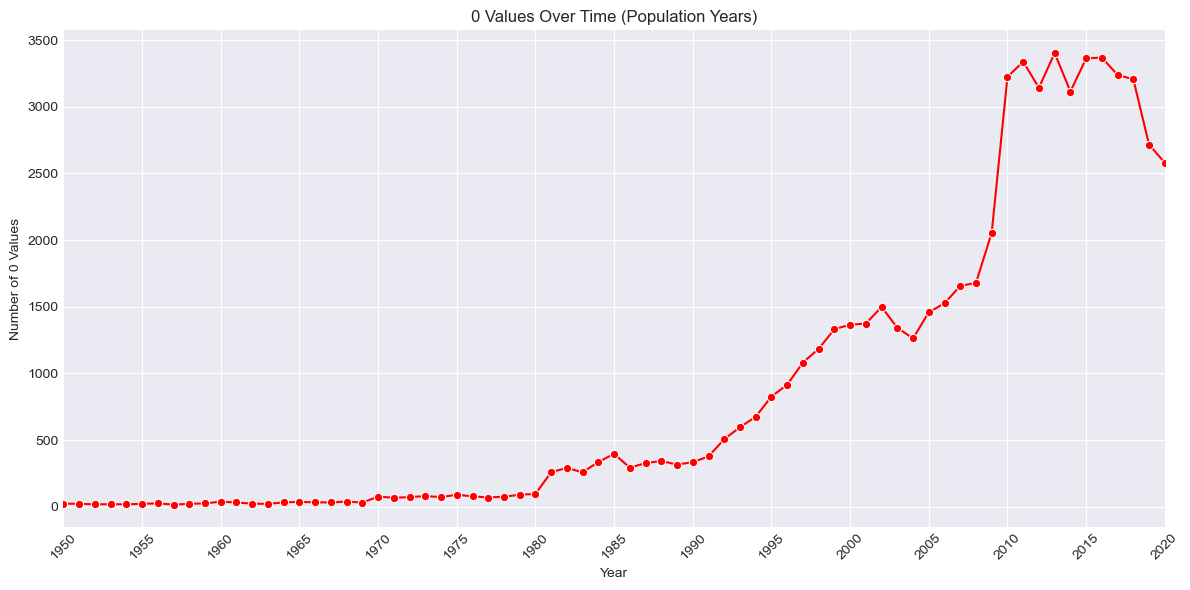

In [ ]:
# 0s values analysis
print("\n0s Values Analysis in Population Years:")
for year in sorted(year_cols):
    zero_count = (df[year] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f"  {year}: {zero_count:6} ({zero_pct:5.1f}%)")

# Tot 0 percentage (over real vales, not missing)
total_values = len(df) * len(year_cols)
total_zeros = sum((df[year_cols] == 0).sum())
total_non_missing = total_values - df[year_cols].isnull().sum().sum()
total_zero_pct = (total_zeros / total_non_missing) * 100 if total_non_missing > 0 else 0
print(f"\nTotal 0s in Population Data: {total_zeros} out of {total_non_missing} non-missing values ({total_zero_pct:.1f}%)")

# 0s plotting over time
zeros_over_time = (df[year_cols] == 0).sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=years, y=zeros_over_time.values, marker='o', color='red')
plt.title('0 Values Over Time (Population Years)')
plt.xlabel('Year')  
plt.ylabel('Number of 0 Values')
tick_years = [y for y in years if y % 5 == 0]
plt.xticks(tick_years, rotation=45)
plt.xlim(years.min(), years.max())
plt.tight_layout()
plt.show()

In [36]:
# Interpretation of missing and 0 values
print("\nInterpretation of Missing and 0 Values:")
print("-" * 80)
print("1. Missing values in population years may indicate:")
print("   - Lack of data collection for certain years or species")
print("   - Data entry issues or unreported populations")
print("   - Species that were not monitored during specific periods")
print("2. 0 values may indicate:")
print("   - Actual recorded population of zero (extinction or local extirpation)")
print("   - Data entry errors or misreporting")
print("   - Species that were present but not observed during surveys")
print("3. The best year with the least missing values can be used for more reliable analyses")
print("4. The high percentage of missing values in certain years may limit the ability to analyze trends over time for those periods")



Interpretation of Missing and 0 Values:
--------------------------------------------------------------------------------
1. Missing values in population years may indicate:
   - Lack of data collection for certain years or species
   - Data entry issues or unreported populations
   - Species that were not monitored during specific periods
2. 0 values may indicate:
   - Actual recorded population of zero (extinction or local extirpation)
   - Data entry errors or misreporting
   - Species that were present but not observed during surveys
3. The best year with the least missing values can be used for more reliable analyses
4. The high percentage of missing values in certain years may limit the ability to analyze trends over time for those periods


Of course, it makes sense that msot zeroes can be found in years when most data was collected.

### 4.3 - POTENTIAL DECLINES (EXTINCTION)


Potential Declines to 0 or Almost 0: 3
  - ID: 14128, Binomial: Lanius_ludovicianus, Class: Aves, System: Terrestrial, Continent: nan
  - ID: 14439, Binomial: Sterna_hirundo, Class: Aves, System: Marine, Continent: nan
  - ID: 14639, Binomial: Brachyramphus_marmoratus, Class: Aves, System: Terrestrial, Continent: nan

Plotting examples of potential declines:


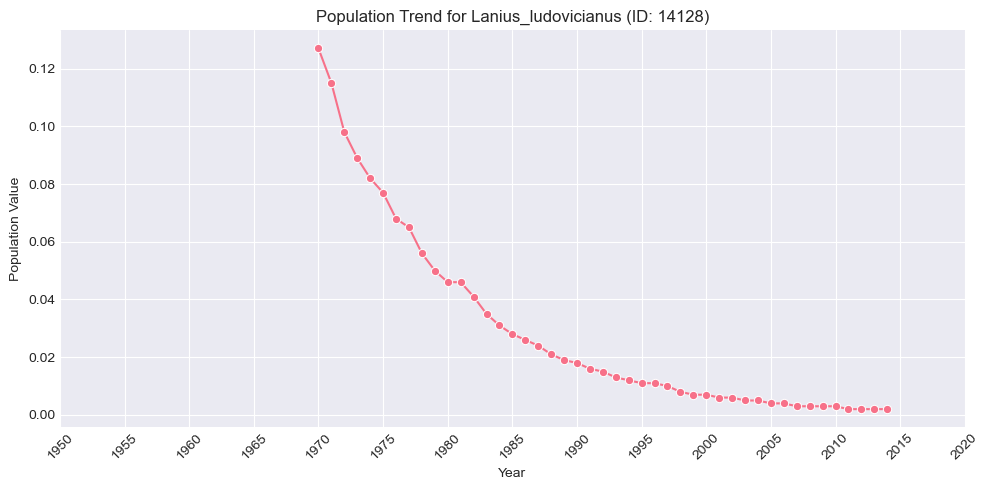

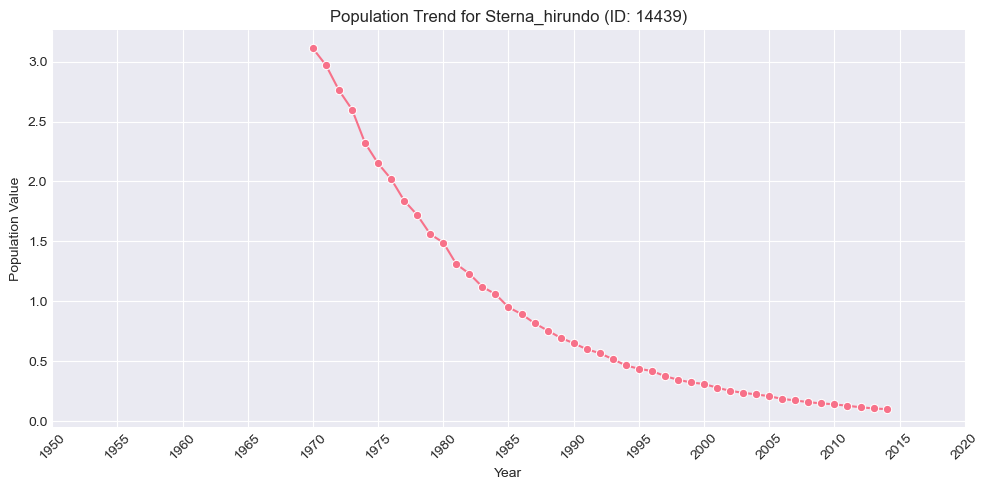

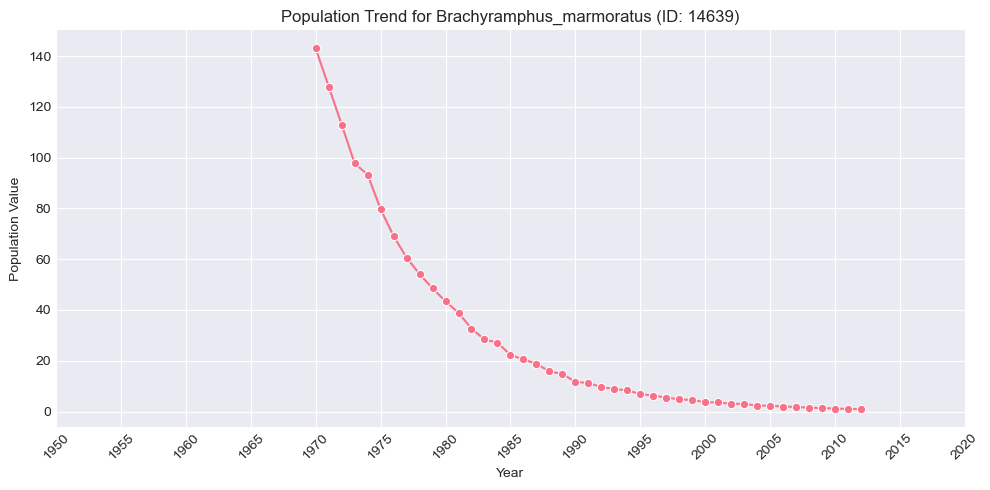

In [40]:
# Years that show a declining trend to 0 or almost 0 values (potentially indicating extinction or severe decline) with at least 5 years of data available (not missing) and not huge gaps in the data (not more than 50% missing values) - this is just a preliminary analysis to identify potential candidates for further investigation + plotting some examples of such cases
potential_declines = []

for _, row in df.iterrows():
    population_values = row[year_cols].astype(float).values

    # Conteggi
    non_missing_mask = ~pd.isnull(population_values)
    non_missing_years = np.sum(non_missing_mask)
    missing_fraction = 1 - (non_missing_years / len(year_cols))

    # Almeno 5 anni disponibili e non più del 50% missing
    if non_missing_years >= 5 and missing_fraction <= 0.5:
        
        max_population = np.nanmax(population_values)

        if max_population > 0:
            threshold = max_population * 0.1

            # Considera solo i valori non nulli per il test di monotonia
            valid_values = population_values[non_missing_mask]

            # Ultimo valore osservato non mancante
            last_value = valid_values[-1]

            # Trend decrescente o costante
            is_non_increasing = all(
                valid_values[i] >= valid_values[i + 1]
                for i in range(len(valid_values) - 1)
            )

            if last_value < threshold and is_non_increasing:
                potential_declines.append((
                    row.get('ID', np.nan),
                    row.get('Binomial', np.nan),
                    row.get('Class', np.nan),
                    row.get('System', np.nan),
                    row.get('Continent', np.nan)   # evita KeyError
                ))

print(f"\nPotential Declines to 0 or Almost 0: {len(potential_declines)}")

for decline in potential_declines[:10]:
    print(
        f"  - ID: {decline[0]}, "
        f"Binomial: {decline[1]}, "
        f"Class: {decline[2]}, "
        f"System: {decline[3]}, "
        f"Continent: {decline[4]}"
    )

# Plot some examples of potential declines
print("\nPlotting examples of potential declines:")
for decline in potential_declines[:5]:  # plot first 5 examples
    record = df[df['ID'] == decline[0]].iloc[0]
    population_values = record[year_cols].astype(float).values
    years = np.array(year_cols).astype(int)

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=years, y=population_values, marker='o')
    plt.title(f"Population Trend for {decline[1]} (ID: {decline[0]})")
    plt.xlabel('Year')
    plt.ylabel('Population Value')
    tick_years = [y for y in years if y % 5 == 0]
    plt.xticks(tick_years, rotation=45)
    plt.xlim(years.min(), years.max())
    plt.tight_layout()
    plt.show()

### 4.4 - COMPLETENESS


Records with at least one population value: 35980 (100.0%)
Records with NO population data: 16 (0.0%)

Distribution of Years with Data per Record:
count    35996.00
mean        11.68
std         12.02
min          0.00
25%          3.00
50%          7.00
75%         15.00
max         71.00
Name: n_years_with_data, dtype: float64


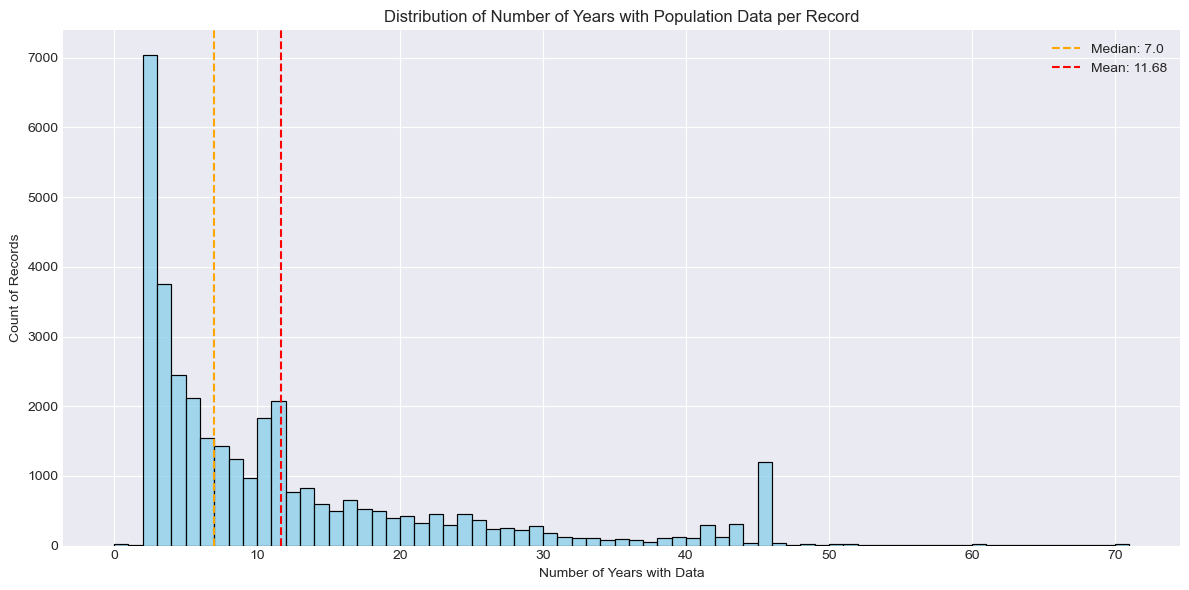


The histogram above shows how many records have population data for a certain number of years. For example, you can see how many records have data for 0 years, 1 year, 2 years, and so on. This helps us understand how complete the population data is across the dataset.


In [41]:
# Completeness: Records with at least some population data
df['has_population_data'] = df[year_cols].notna().any(axis=1)
df['n_years_with_data'] = df[year_cols].notna().sum(axis=1)

print(f"\nRecords with at least one population value: {df['has_population_data'].sum()} ({df['has_population_data'].sum()/len(df)*100:.1f}%)")
print(f"Records with NO population data: {(~df['has_population_data']).sum()} ({(~df['has_population_data']).sum()/len(df)*100:.1f}%)")

print("\nDistribution of Years with Data per Record:")
print(df['n_years_with_data'].describe().round(2))

# Plot distribution of years with data (only shows a few lables in x axis, but gives an idea of completeness)
# Show median and mean lines for reference
plt.figure(figsize=(12, 6))
sns.histplot(df['n_years_with_data'], bins=range(0, len(year_cols)+1), kde=False, color='skyblue')
plt.axvline(df['n_years_with_data'].median(), color='orange', linestyle='--', label=f'Median: {df["n_years_with_data"].median()}')
plt.axvline(df['n_years_with_data'].mean(), color='red', linestyle='--', label=f'Mean: {df["n_years_with_data"].mean():.2f}')
plt.title('Distribution of Number of Years with Population Data per Record')
plt.xlabel('Number of Years with Data')
plt.ylabel('Count of Records')
plt.legend()
plt.tight_layout()
plt.show()

# Print explanatio of plots in simple terms
print("\nThe histogram above shows how many records have population data for a certain number of years. For example, you can see how many records have data for 0 years, 1 year, 2 years, and so on. This helps us understand how complete the population data is across the dataset.")     

### 4.4 - POTENTIAL USABLE POPULATIONS 

(ACROSS ALL SPECIES INCLUDING LAND AND MARINE)

Populations with >=20 years of data and reaching 2020: 1151

Summary of maximum consecutive gaps:
count    1151.000000
mean       39.024327
std         8.992331
min         0.000000
25%        31.000000
50%        42.000000
75%        46.000000
max        51.000000
Name: max_consecutive_gaps, dtype: float64

Continuous populations (no gaps): 11
Populations with at least one gap: 1140
Average maximum consecutive gaps: 39.02
Maximum consecutive gaps observed: 51
Populations with gaps below or equal to 2 years: 11 (1.0%)


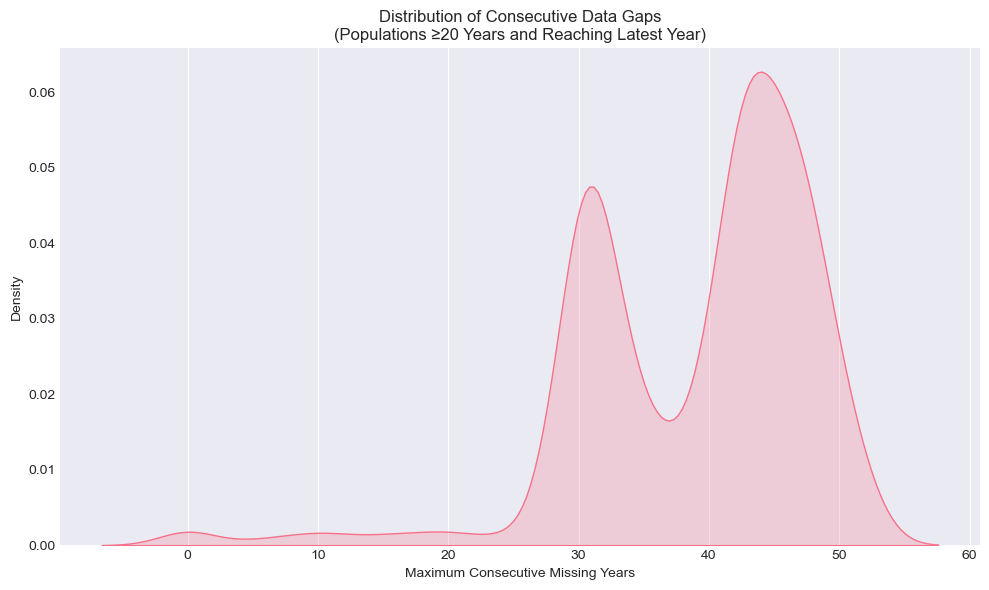

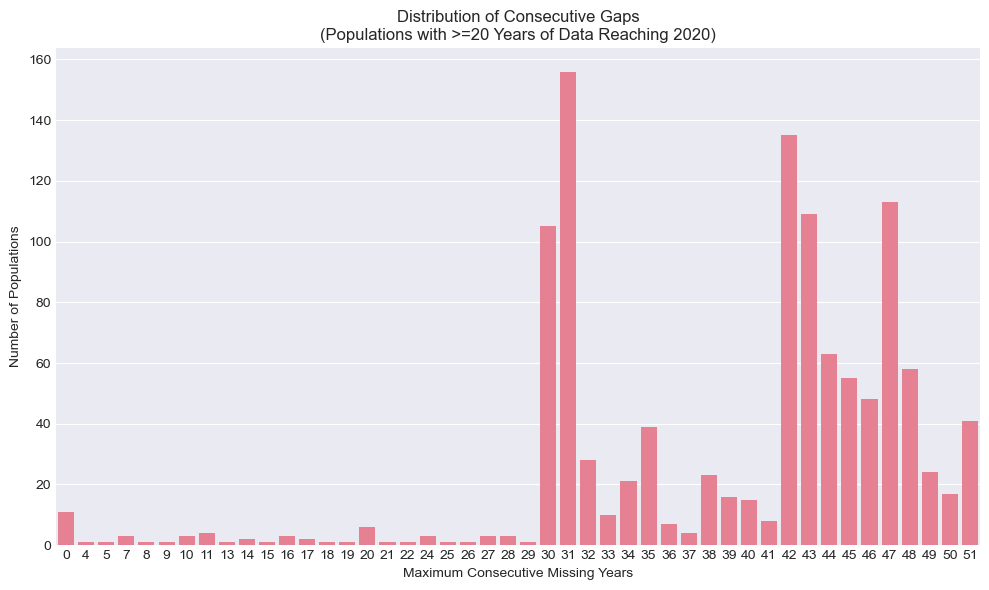

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure the year columns are correctly ordered
year_cols = sorted(year_cols, key=int)

# Latest year available in the dataset
last_year = year_cols[-1]

# Count how many years with data each population has
df["n_years_with_data"] = df[year_cols].notna().sum(axis=1)

# Keep only populations with:
# - at least 20 years of data
# - a value present in the latest available year
usable_populations = df[
    (df["n_years_with_data"] >= 20) &
    (df[last_year].notna())
].copy()

print(f"Populations with >=20 years of data and reaching {last_year}: {len(usable_populations)}")

# Function to calculate the maximum number of consecutive missing years
def max_consecutive_gaps(row):
    gaps = row.isna().astype(int)

    max_gap = 0
    current_gap = 0

    for g in gaps:
        if g == 1:
            current_gap += 1
            max_gap = max(max_gap, current_gap)
        else:
            current_gap = 0

    return max_gap

# Calculate the maximum consecutive gap for each population
usable_populations["max_consecutive_gaps"] = usable_populations[year_cols].apply(
    max_consecutive_gaps, axis=1
)

# Print some useful summary statistics
print("\nSummary of maximum consecutive gaps:")
print(usable_populations["max_consecutive_gaps"].describe())

continuous = (usable_populations["max_consecutive_gaps"] == 0).sum()
print(f"\nContinuous populations (no gaps): {continuous}")
print(f"Populations with at least one gap: {len(usable_populations) - continuous}")
print(f"Average maximum consecutive gaps: {usable_populations['max_consecutive_gaps'].mean():.2f}")
print(f"Maximum consecutive gaps observed: {usable_populations['max_consecutive_gaps'].max()}")
print(f"Populations with gaps below or equal to 2 years: {(usable_populations['max_consecutive_gaps'] <= 2).sum()} ({(usable_populations['max_consecutive_gaps'] <= 2).mean()*100:.1f}%)")

# =========================
# PLOT 1: gap distribution
# =========================
plt.figure(figsize=(10, 6))

sns.kdeplot(
    usable_populations["max_consecutive_gaps"],
    fill=True
)

plt.title("Distribution of Consecutive Data Gaps\n(Populations ≥20 Years and Reaching Latest Year)")
plt.xlabel("Maximum Consecutive Missing Years")
plt.ylabel("Density")

plt.grid(axis="y")
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: exact count by gap length
# =========================
gap_counts = usable_populations["max_consecutive_gaps"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=gap_counts.index, y=gap_counts.values)

plt.title(f"Distribution of Consecutive Gaps\n(Populations with >=20 Years of Data Reaching {last_year})")
plt.xlabel("Maximum Consecutive Missing Years")
plt.ylabel("Number of Populations")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

### 4.5 - POPULATIONS WITH ABRUPT CHANGES IN RATE

Usable populations (>=20 years of data and reaching 2020): 1151

Top 5 populations with highest overall increase rate:
                       Binomial first_year last_year  first_value  last_value  \
15370       Gadus_chalcogrammus       1963      2020    1524000.0   6900000.0   
15344       Gadus_chalcogrammus       1994      2020     785000.0   1753000.0   
15358  Micromesistius_poutassou       1981      2020    2840000.0   4150000.0   
5393        Gadus_chalcogrammus       1964      2020     489048.0   1925940.0   
1474      Pleuronectes_platessa       1957      2020     342000.0    905000.0   

       overall_change_rate  
15370         94315.789474  
15344         37230.769231  
15358         33589.743590  
5393          25658.785714  
1474           8936.507937  

Top 5 populations with highest overall decrease rate:
                      Binomial first_year last_year  first_value  \
15263        Trachurus_murphyi       1970      2020   14378000.0   
35959  Macruronus_magellanicu

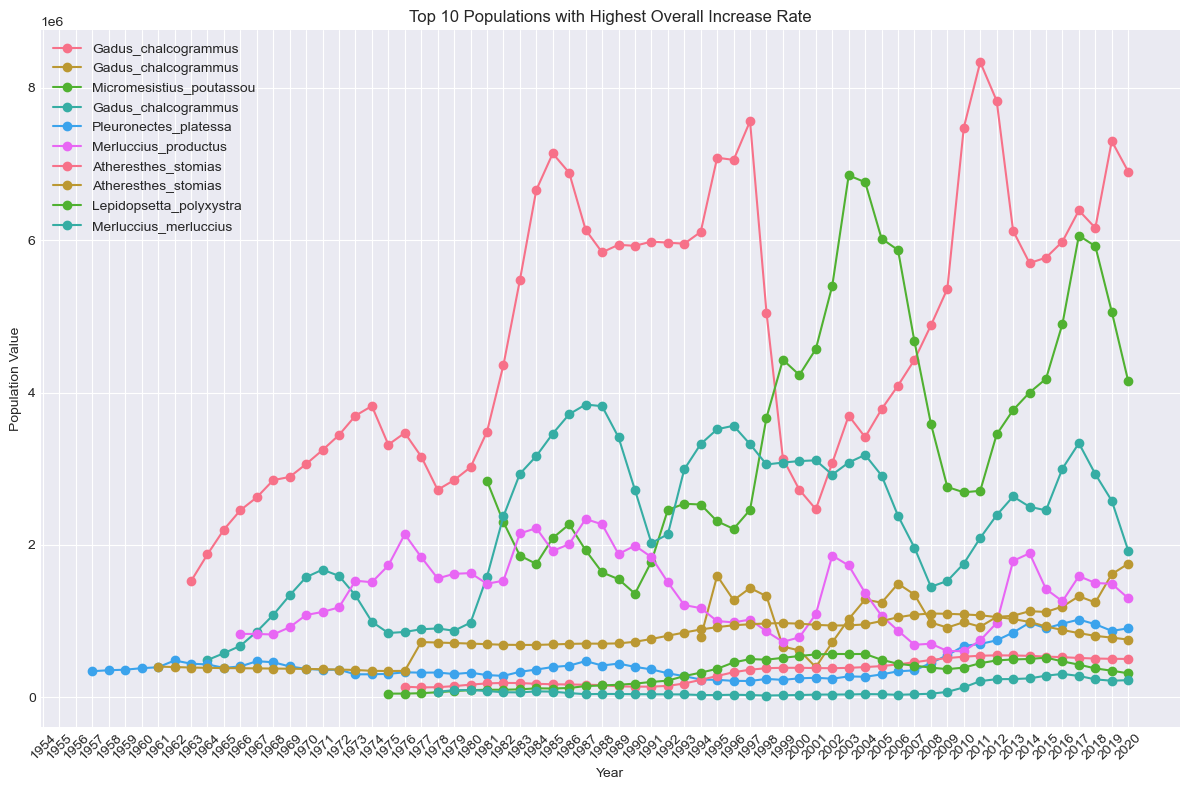

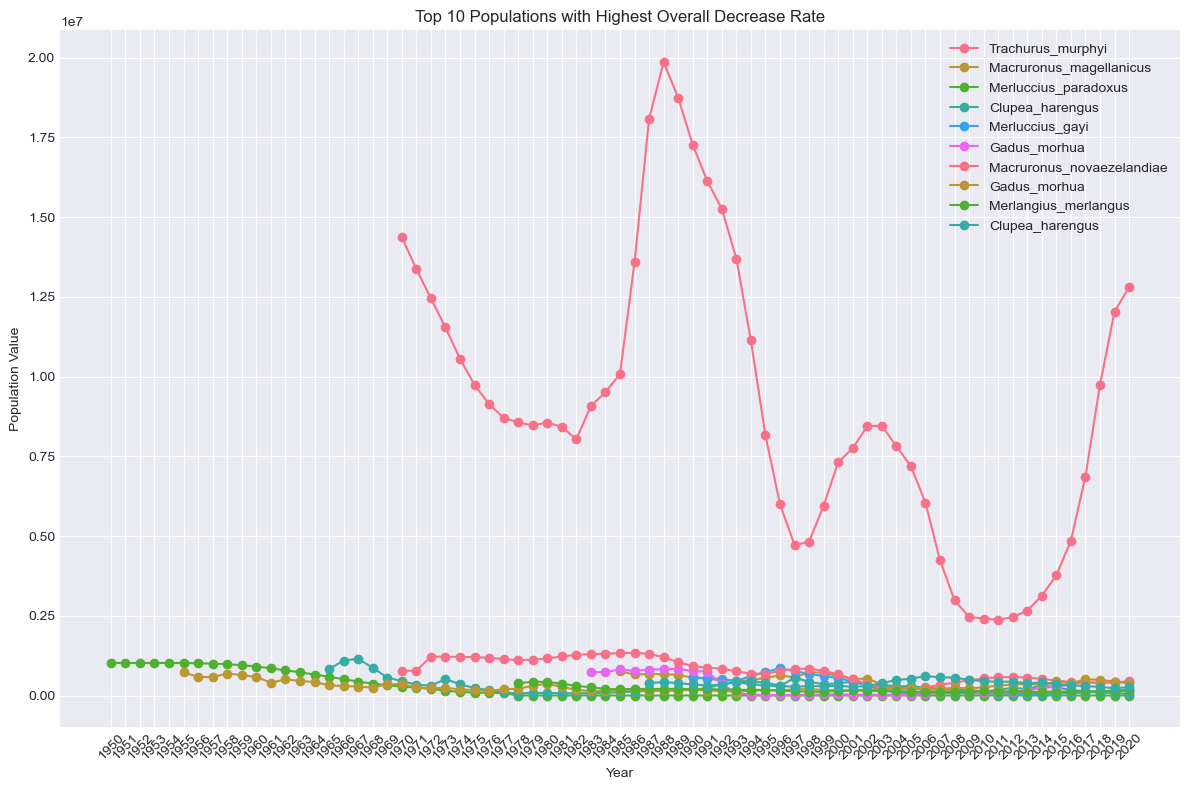

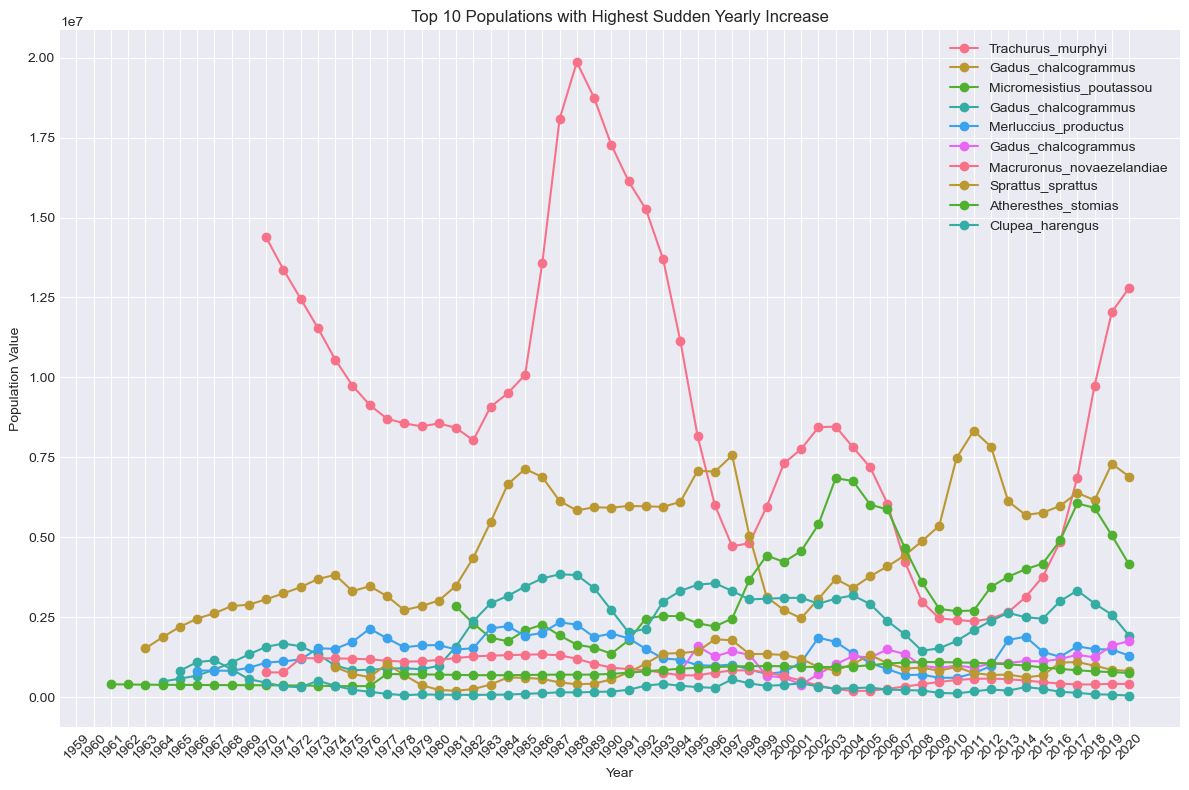

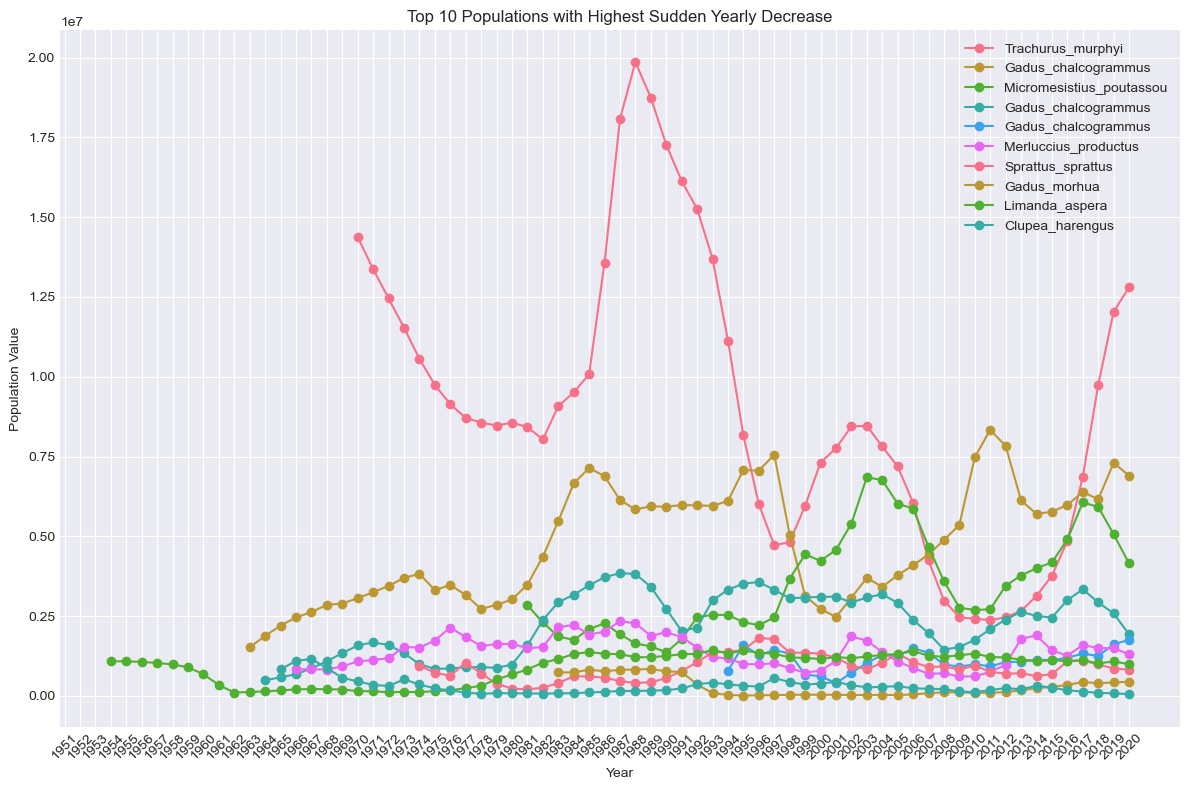

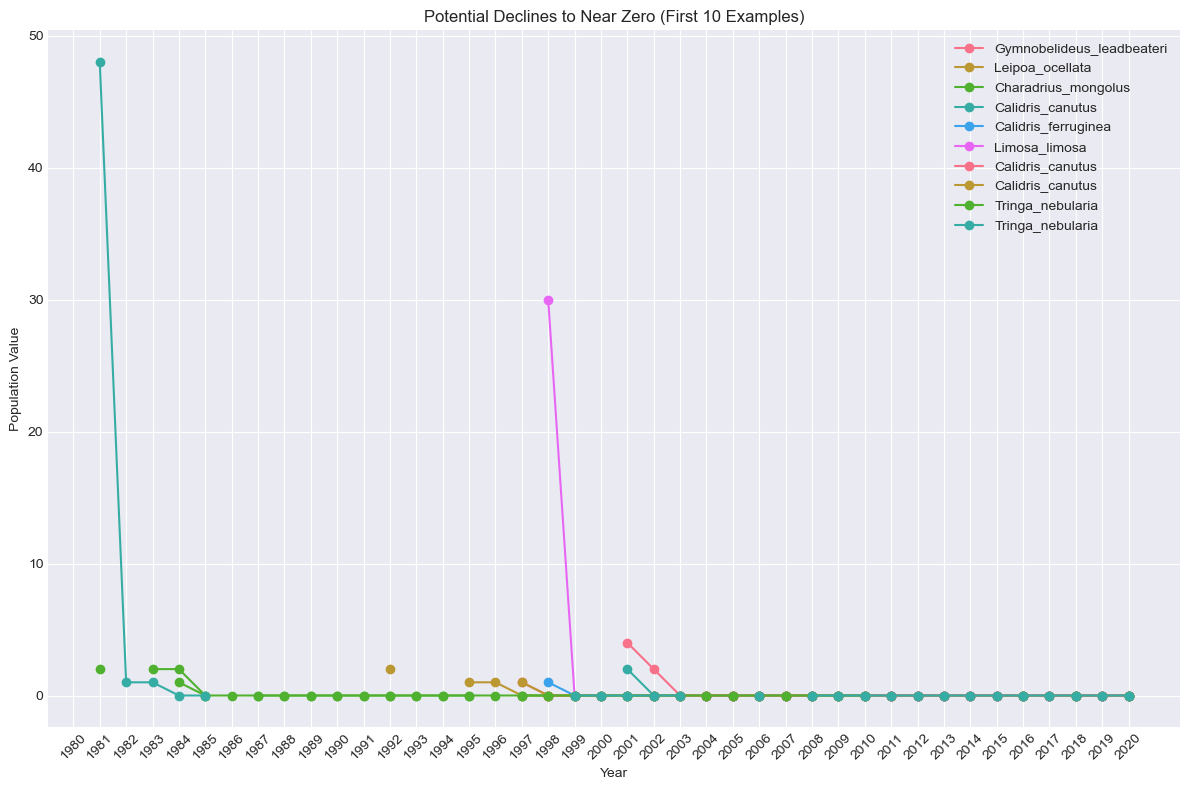

In [ ]:
# =========================================
# 1. Prepare usable populations
# =========================================

# Make sure year columns are ordered correctly
year_cols = sorted(year_cols, key=int)

# Latest year available
last_year_dataset = year_cols[-1]

# Count number of years with available data
df["n_years_with_data"] = df[year_cols].notna().sum(axis=1)

# Keep only populations with:
# - at least 20 years of data
# - a value in the latest available year
usable_populations = df[
    (df["n_years_with_data"] >= 20) &
    (df[last_year_dataset].notna())
].copy()

print(f"Usable populations (>=20 years of data and reaching {last_year_dataset}): {len(usable_populations)}")

# =========================================
# 2. Compute summary metrics
# =========================================

# First and last valid years
usable_populations["first_year"] = usable_populations[year_cols].apply(
    lambda row: row.first_valid_index(), axis=1
)
usable_populations["last_year"] = usable_populations[year_cols].apply(
    lambda row: row.last_valid_index(), axis=1
)

# First and last valid values
usable_populations["first_value"] = usable_populations.apply(
    lambda row: row[row["first_year"]] if pd.notna(row["first_year"]) else np.nan,
    axis=1
)
usable_populations["last_value"] = usable_populations.apply(
    lambda row: row[row["last_year"]] if pd.notna(row["last_year"]) else np.nan,
    axis=1
)

# Time span for each population
usable_populations["year_span"] = (
    usable_populations["last_year"].astype(int) -
    usable_populations["first_year"].astype(int)
)

# Overall change rate
usable_populations["overall_change_rate"] = (
    (usable_populations["last_value"] - usable_populations["first_value"]) /
    usable_populations["year_span"]
)

# Year-to-year changes
yearly_changes = usable_populations[year_cols].diff(axis=1)

# Maximum yearly increase and decrease
usable_populations["max_yearly_increase"] = yearly_changes.max(axis=1)
usable_populations["year_of_max_increase"] = yearly_changes.idxmax(axis=1)

usable_populations["max_yearly_decrease"] = yearly_changes.min(axis=1)
usable_populations["year_of_max_decrease"] = yearly_changes.idxmin(axis=1)

# =========================================
# 3. Identify potential declines to near zero
# =========================================

potential_declines = []

for idx, row in usable_populations.iterrows():
    population_values = row[year_cols].astype(float).values
    non_missing_mask = ~pd.isnull(population_values)
    valid_values = population_values[non_missing_mask]

    if len(valid_values) >= 5:
        max_population = np.nanmax(valid_values)

        if max_population > 0:
            threshold = max_population * 0.1
            last_value = valid_values[-1]

            # Non-increasing trend
            is_non_increasing = all(
                valid_values[i] >= valid_values[i + 1]
                for i in range(len(valid_values) - 1)
            )

            if last_value < threshold and is_non_increasing:
                potential_declines.append(idx)

usable_populations["potential_decline_to_zero"] = False
usable_populations.loc[potential_declines, "potential_decline_to_zero"] = True

# =========================================
# 4. Print results
# =========================================

print("\nTop 5 populations with highest overall increase rate:")
print(
    usable_populations.sort_values("overall_change_rate", ascending=False)[
        ["Binomial", "first_year", "last_year", "first_value", "last_value", "overall_change_rate"]
    ].head(5)
)

print("\nTop 5 populations with highest overall decrease rate:")
print(
    usable_populations.sort_values("overall_change_rate", ascending=True)[
        ["Binomial", "first_year", "last_year", "first_value", "last_value", "overall_change_rate"]
    ].head(5)
)

print("\nTop 5 populations with highest sudden yearly increase:")
print(
    usable_populations.sort_values("max_yearly_increase", ascending=False)[
        ["Binomial", "max_yearly_increase", "year_of_max_increase"]
    ].head(5)
)

print("\nTop 5 populations with highest sudden yearly decrease:")
print(
    usable_populations.sort_values("max_yearly_decrease", ascending=True)[
        ["Binomial", "max_yearly_decrease", "year_of_max_decrease"]
    ].head(5)
)

print("\nNumber of populations with potential decline to near zero:")
print(usable_populations["potential_decline_to_zero"].sum())

print("\nFirst 10 potential decline-to-near-zero populations:")
print(
    usable_populations[usable_populations["potential_decline_to_zero"]][
        ["Binomial", "first_value", "last_value", "overall_change_rate"]
    ].head(10)
)

# =========================================
# 5. Plot function
# =========================================

def plot_top_species(data, metric, ascending, title, n=10):
    top_species = data.sort_values(metric, ascending=ascending).head(n)

    plt.figure(figsize=(12, 8))

    for _, row in top_species.iterrows():
        species_data = row[year_cols]
        plt.plot(year_cols, species_data, marker='o', label=row["Binomial"])

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Population Value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================
# 6. Plots
# =========================================

plot_top_species(
    usable_populations,
    metric="overall_change_rate",
    ascending=False,
    title="Top 10 Populations with Highest Overall Increase Rate"
)

plot_top_species(
    usable_populations,
    metric="overall_change_rate",
    ascending=True,
    title="Top 10 Populations with Highest Overall Decrease Rate"
)

plot_top_species(
    usable_populations,
    metric="max_yearly_increase",
    ascending=False,
    title="Top 10 Populations with Highest Sudden Yearly Increase"
)

plot_top_species(
    usable_populations,
    metric="max_yearly_decrease",
    ascending=True,
    title="Top 10 Populations with Highest Sudden Yearly Decrease"
)

# Plot potential decline to near zero populations
decline_candidates = usable_populations[
    usable_populations["potential_decline_to_zero"]
].head(10)

if len(decline_candidates) > 0:
    plt.figure(figsize=(12, 8))

    for _, row in decline_candidates.iterrows():
        species_data = row[year_cols]
        plt.plot(year_cols, species_data, marker='o', label=row["Binomial"])

    plt.title("Potential Declines to Near Zero (First 10 Examples)")
    plt.xlabel("Year")
    plt.ylabel("Population Value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nNo potential decline-to-near-zero populations found.")

### 4.6 - METADATA COLUMNS SUMMARY

---
# **5 - TRENDS & DISTRIBUTIONS**

### 5.1 - TAXONOMIC ANALYSIS

In [ ]:
# Taxonomic columns
taxonomic_cols = ['Class', 'Order', 'Family', 'Genus', 'Species', 'Common_name', 'Binomial']
available_taxonomic = [col for col in taxonomic_cols if col in df.columns]

print(f"Available taxonomic columns: {available_taxonomic}")

# Check unique species
for col in available_taxonomic:
    if col in df.columns:
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")

Available taxonomic columns: ['Class', 'Order', 'Family', 'Genus', 'Species', 'Common_name', 'Binomial']

Class: 11 unique values
  Missing: 0 (0.0%)

Order: 134 unique values
  Missing: 0 (0.0%)

Family: 647 unique values
  Missing: 0 (0.0%)

Genus: 2585 unique values
  Missing: 0 (0.0%)

Species: 3736 unique values
  Missing: 0 (0.0%)

Common_name: 4880 unique values
  Missing: 0 (0.0%)

Binomial: 5177 unique values
  Missing: 0 (0.0%)


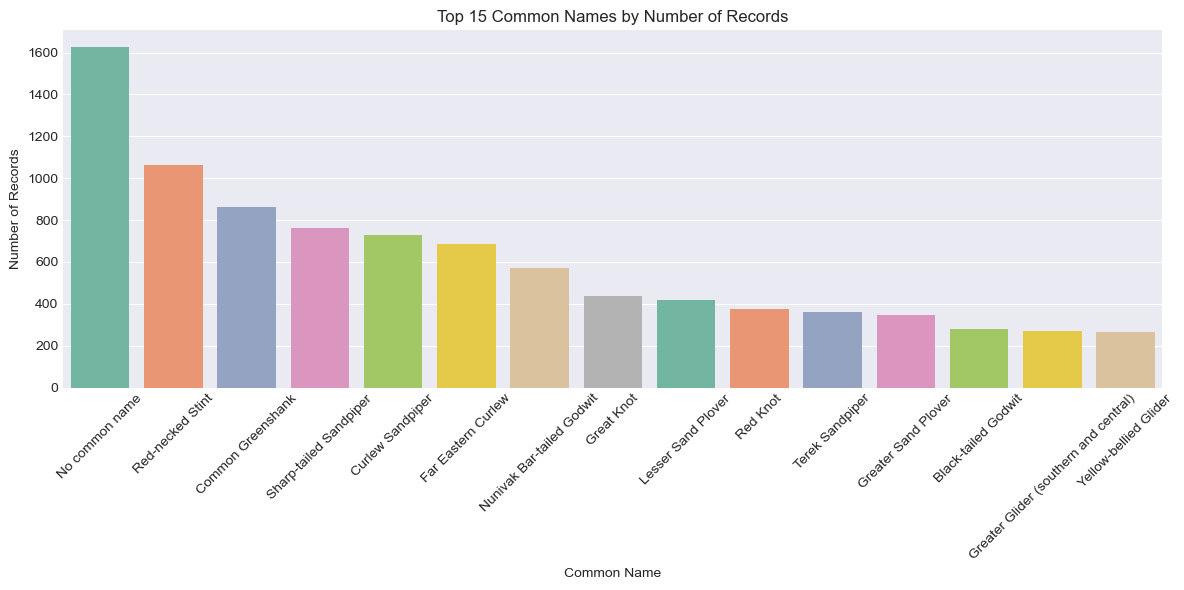

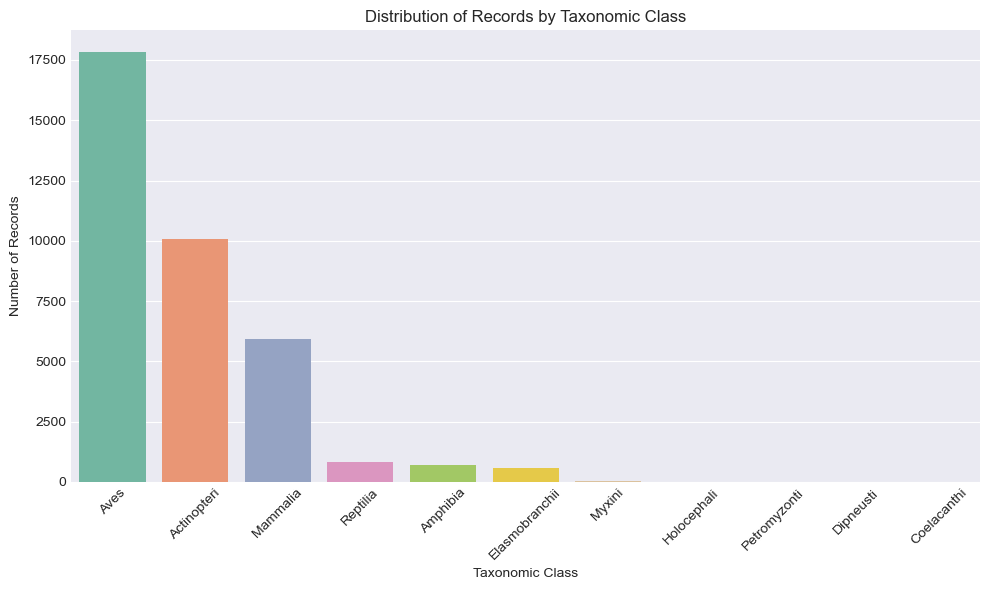

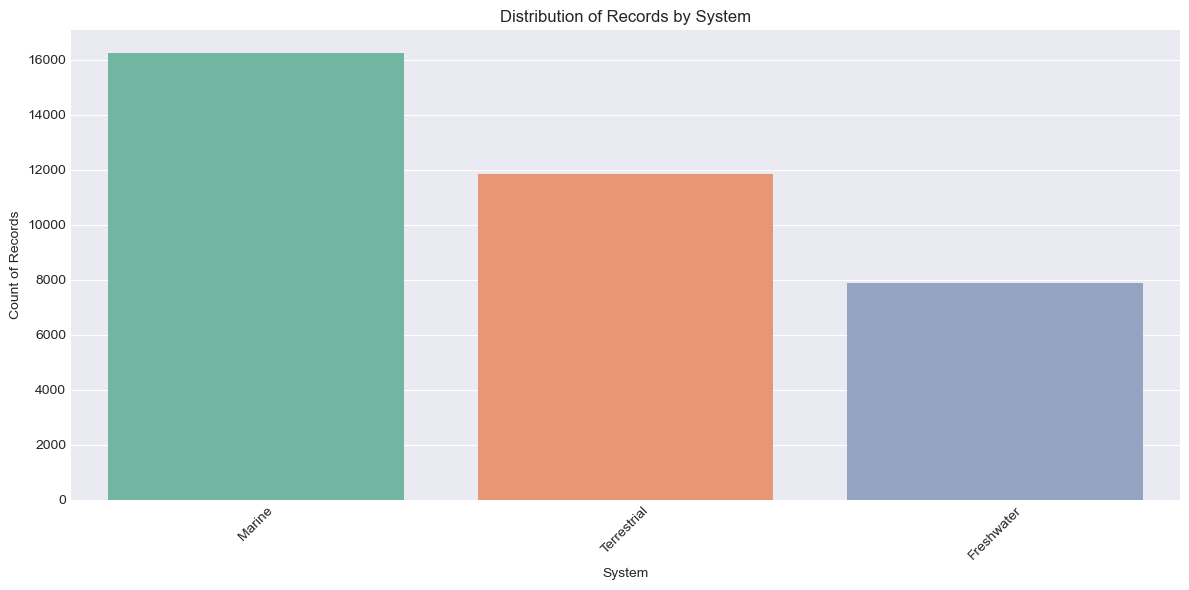

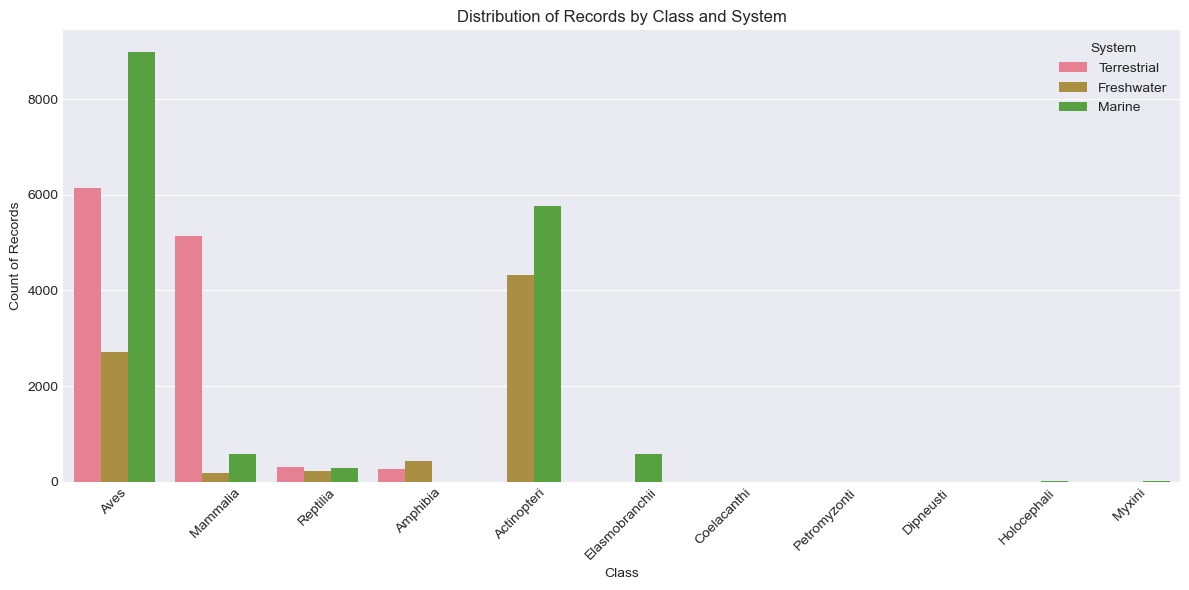

In [95]:
# Distribution of records by common name (top 15)
if 'Common_name' in df.columns:
    plt.figure(figsize=(12, 6))
    top_common_names = df['Common_name'].value_counts().head(15).index
    sns.countplot(data=df[df['Common_name'].isin(top_common_names)], x='Common_name', order=top_common_names, palette='Set2')
    plt.title('Top 15 Common Names by Number of Records')
    plt.xlabel('Common Name')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if 'Class' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Class', order=df['Class'].value_counts().index, palette='Set2')
    plt.title('Distribution of Records by Taxonomic Class')
    plt.xlabel('Taxonomic Class')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if 'System' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='System', order=df['System'].value_counts().index, palette='Set2')
    plt.title('Distribution of Records by System')
    plt.xlabel('System')
    plt.ylabel('Count of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Distribution by Class and System
if 'Class' in df.columns and 'System' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='Class', hue='System')
    plt.title('Distribution of Records by Class and System')
    plt.xlabel('Class')
    plt.ylabel('Count of Records')
    plt.xticks(rotation=45)
    plt.legend(title='System')
    plt.tight_layout()
    plt.show()


In [ ]:
# Species analysis
print("\nSpecies Distribution:")
print("-" * 80)
unique_species = df['Binomial'].nunique()
print(f"Unique Species: {unique_species}")
print(f"Average Replicates per Species: {len(df) / unique_species:.2f}")

print("\nTop 10 Most Replicated Species:")
species_counts = df['Binomial'].value_counts().head(10)
for species, count in species_counts.items():
    print(f"  {species:40} {count:3} records")

# Explain what replicates means in this context
print("\nExplanation of Replicates:")
print("Replicates refer to multiple observations or measurements of the same species within the dataset. This can occur when the same species is recorded across different locations, time periods, or studies.")       


Species Distribution:
--------------------------------------------------------------------------------
Unique Species: 5177
Average Replicates per Species: 6.95

Top 10 Most Replicated Species:
  Calidris_ruficollis                      1083 records
  Tringa_nebularia                         879 records
  Limosa_lapponica                         829 records
  Calidris_acuminata                       777 records
  Calidris_ferruginea                      759 records
  Numenius_madagascariensis                696 records
  Calidris_tenuirostris                    451 records
  Charadrius_mongolus                      420 records
  Calidris_canutus                         416 records
  Xenus_cinereus                           362 records

Explanation of Replicates:
Replicates refer to multiple observations or measurements of the same species within the dataset. This can occur when the same species is recorded across different locations, time periods, or studies.

Number of Countries: 202

### 5.2 - SPATIAL/GEOGRAPHIC ANALYSIS

In [62]:
# Geographic distribution
geo_cols = ['Latitude', 'Longitude', 'Location', 'Country', 'Region']
available_geo = [col for col in geo_cols if col in df.columns]

print(f"Available geographic columns: {available_geo}")

for col in available_geo:
    if col in df.columns:
        print(f"\n{col}:")
        if df[col].dtype in ['float64', 'int64']:
            print(f"  Range: {df[col].min()} to {df[col].max()}")
            print(f"  Mean: {df[col].mean():.2f}")
        else:
            print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")

Available geographic columns: ['Latitude', 'Longitude', 'Location', 'Country', 'Region']

Latitude:
  Range: -78.193822 to 81.0
  Mean: 8.61
  Missing: 0 (0.0%)

Longitude:
  Range: -180.0 to 180.0
  Mean: 21.00
  Missing: 0 (0.0%)

Location:
  Unique values: 7678
  Missing: 0 (0.0%)

Country:
  Unique values: 202
  Missing: 0 (0.0%)

Region:
  Unique values: 8
  Missing: 0 (0.0%)


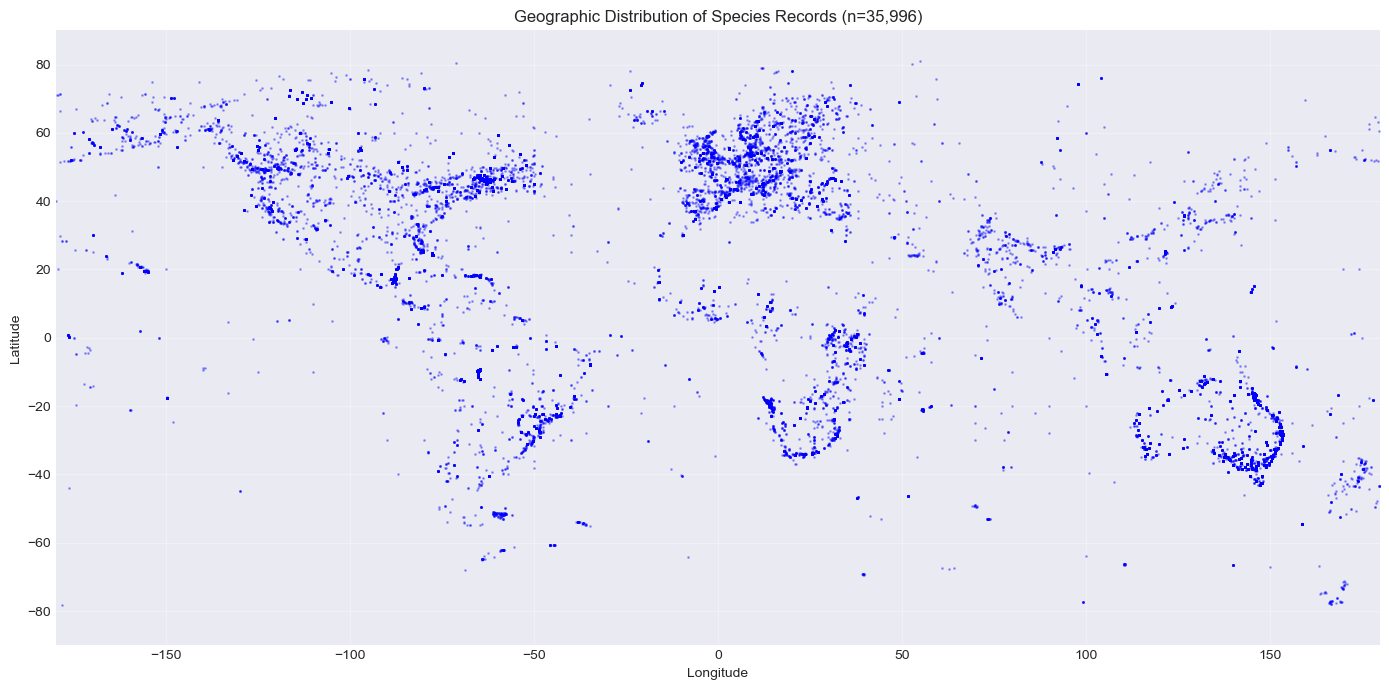


Records with valid coordinates: 35,996 (100.0%)


In [66]:
# Plot geographic distribution
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    plt.figure(figsize=(14, 7))
    
    # Filter out missing coordinates
    valid_coords = df[['Latitude', 'Longitude']].dropna()
    
    plt.scatter(valid_coords['Longitude'], valid_coords['Latitude'], 
                alpha=0.3, s=1, c='blue')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Geographic Distribution of Species Records (n={len(valid_coords):,})')
    plt.grid(True, alpha=0.3)
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.tight_layout()
    plt.show()
    
    print(f"\nRecords with valid coordinates: {len(valid_coords):,} ({len(valid_coords)/len(df)*100:.1f}%)")


Number of Countries: 202

Top 15 Countries:
Country
Australia         11413
Canada             6297
Brazil             3693
United States      2066
Spain               870
United Kingdom      665
Norway              593
South Africa        568
France              470
Germany             320
India               309
Namibia             298
Italy               292
Belize              285
Bahamas             282
Name: count, dtype: int64


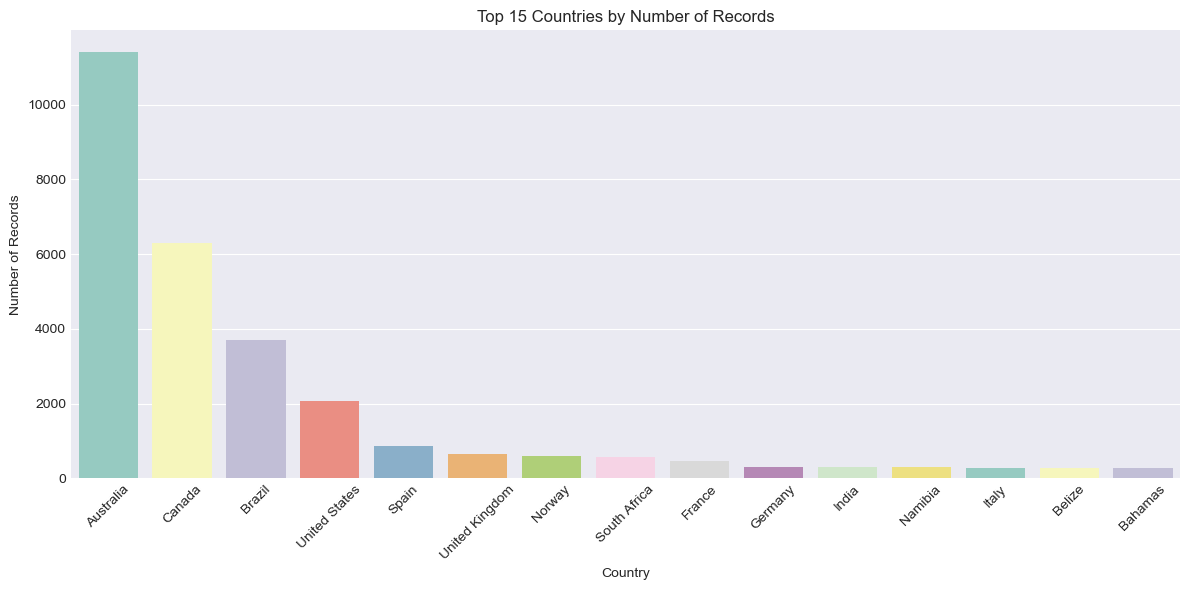

In [ ]:
if 'Country' in df.columns:
    print(f"\nNumber of Countries: {df['Country'].nunique()}")
    print("\nTop 15 Countries:")
    print(df['Country'].value_counts().head(15))

# Distribution of records by country (top 15)
if 'Country' in df.columns:
    plt.figure(figsize=(12, 6))
    top_countries = df['Country'].value_counts().head(15).index
    sns.countplot(data=df[df['Country'].isin(top_countries)], x='Country', order=top_countries, palette='Set3')
    plt.title('Top 15 Countries by Number of Records')
    plt.xlabel('Country')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Distribution of Records by Continent:
Continent
Oceania          11753
North America     9783
Europe            5737
South America     4228
Africa            2678
Asia              1290
Other              527
Name: count, dtype: int64


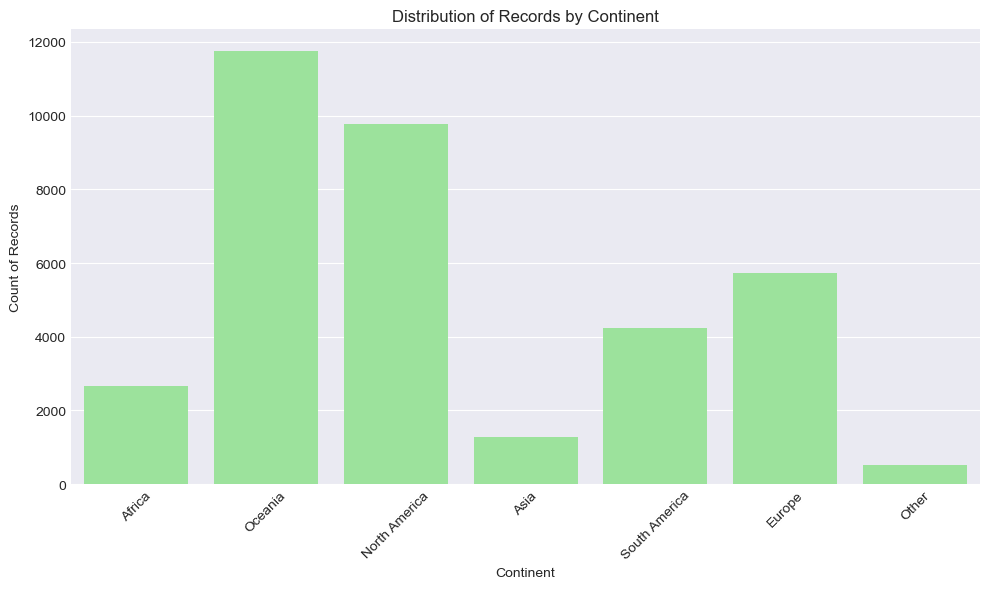


Distribution of Records by Continent (Based on Coordinates):
Continent_by_Coordinates
Oceania          11507
North America     9168
Africa            6068
South America     4243
Other             3133
Asia              1150
Europe             727
Name: count, dtype: int64

Continent Mapping Comparison:
Continent_by_Coordinates  Africa  Asia  Europe  North America  Oceania  Other  \
Continent                                                                       
Africa                      1314     0       0              0        0   1364   
Asia                          39  1044       0              0       32    175   
Europe                      4701    54     726              8        0    248   
North America                  0     0       0           9129        0    599   
Oceania                        0    47       0              1    11470    235   
Other                         14     5       1             30        5    462   
South America                  0     0       0 

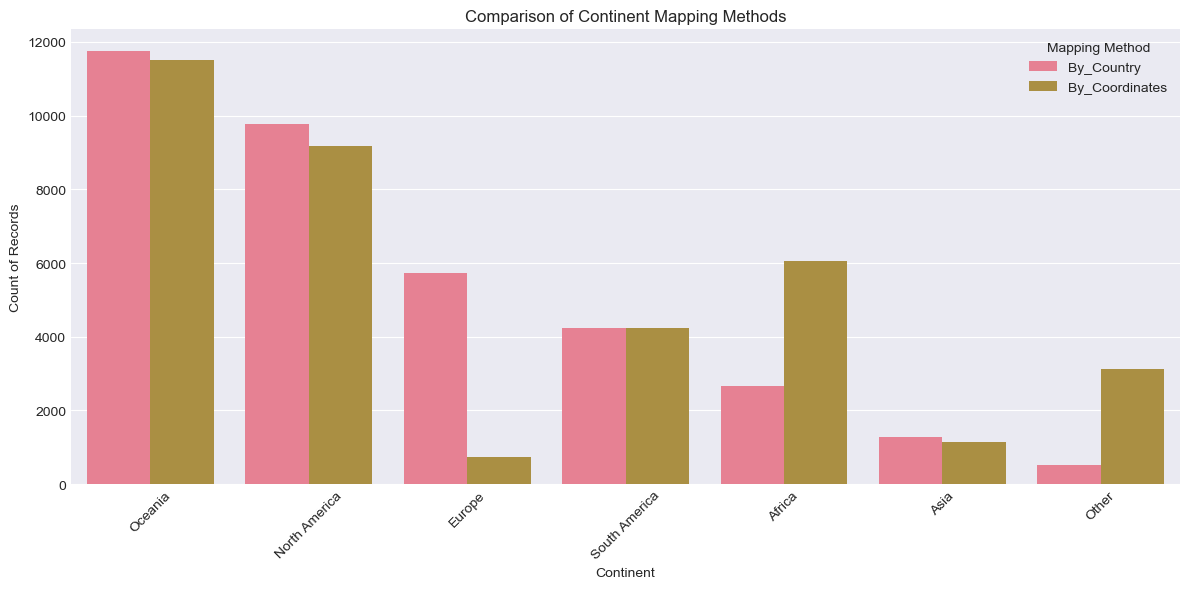


Continent Mapping Comparison with Misclassification:
Continent_by_Coordinates  Misclassified  Total  Misclassification_Percentage
Continent                                                                   
Africa                             1364   4042                     33.745670
Asia                                246   1536                     16.015625
Europe                             5011  10748                     46.622627
North America                       654  10437                      6.266168
Oceania                             283  12036                      2.351279
Other                               527   1054                     50.000000
South America                        50   4278                      1.168770


In [ ]:
countries = ['Uganda' 'Seychelles' 'Mauritius' 'Djibouti' 'Botswana' 'Lesotho'
 'Mozambique' 'Namibia' 'South Africa' 'Eswatini'
 'Tanzania, United Republic Of' 'Kenya' "Côte D'Ivoire" 'Nigeria'
 'Ethiopia' 'Congo, The Democratic Republic Of The' 'Cameroon'
 'Central African Republic' 'Niger' 'Zambia' 'Rwanda' 'Zimbabwe' 'Comoros'
 'Senegal' 'Malawi' 'New Zealand' 'Norfolk Island' 'Australia'
 'United States' 'French Polynesia' 'Guam' 'India' 'Pakistan' 'Nepal'
 'Bangladesh' 'China' 'Malaysia' 'Indonesia' 'Viet Nam' 'Puerto Rico'
 'Dominica' 'Bahamas' 'Venezuela, Bolivarian Republic Of' 'Cayman Islands'
 'Saint Lucia' 'Paraguay' 'Chile' 'Brazil' 'Costa Rica' 'Panama'
 'Virgin Islands, British' 'United Kingdom' 'Sweden' 'Netherlands'
 'Denmark' 'Germany' 'Greenland' 'Svalbard And Jan Mayen' 'Azerbaijan'
 'Poland' 'Serbia' 'Russian Federation' 'Estonia' 'Finland' 'Bulgaria'
 'Latvia' 'Morocco' 'Türkiye' 'France' 'Spain' 'Italy' 'Austria' 'Hungary'
 'Switzerland' 'Lithuania' 'Slovakia' 'Portugal' 'Norway' 'Czechia'
 'Slovenia' 'Croatia' 'Romania' 'Greece' 'Uzbekistan' 'Israel'
 'Tajikistan' 'Belgium' 'Algeria' 'Japan' 'Iran, Islamic Republic Of'
 'Mongolia' 'Ukraine' 'Kazakhstan' 'Turkmenistan' 'Albania'
 'Papua New Guinea' 'Mali' 'Hong Kong' 'Philippines' 'Canada' 'Mexico'
 'Bolivia, Plurinational State Of' 'Peru' 'Guatemala' 'Dominican Republic'
 'Ecuador' 'Iceland' 'Faroe Islands' 'International Waters'
 'South Georgia And The South Sandwich Islands' 'Ireland' 'Cuba'
 'Argentina' 'Malta' 'Cyprus' 'Bermuda' 'Western Sahara' 'Suriname'
 'Virgin Islands, U.S.' 'Antigua And Barbuda'
 'United States Minor Outlying Islands' 'Taiwan, Province Of China'
 'Christmas Island' 'United Arab Emirates' 'French Southern Territories'
 'Antarctica' 'Heard Island And McDonald Islands'
 'Falkland Islands (Malvinas)' 'Colombia' 'Cook Islands'
 'Saint Helena, Ascension And Tristan Da Cunha' 'Myanmar' 'Guinea Bissau'
 'Saudi Arabia' 'Thailand' 'Angola' 'Oman' 'American Samoa' 'Burundi'
 'British Indian Ocean Territory' 'Korea, Republic Of' 'Benin' 'Belarus'
 'South Sudan' 'Chad' 'Somalia' 'Ghana' 'Mauritania' 'Madagascar'
 'Liberia' 'Sierra Leone' 'Guinea' 'Gabon' 'Gibraltar' 'French Guiana'
 "Lao People's Democratic Republic" 'Syrian Arab Republic' 'Tunisia'
 'Samoa' 'Montenegro' 'North Macedonia' 'Egypt' 'Belize' 'Fiji' 'Uruguay'
 'Jersey' 'Barbados' 'Sri Lanka' 'Solomon Islands' 'Kuwait' 'Guadeloupe'
 'Kiribati' 'Cambodia' 'New Caledonia' 'Cabo Verde'
 'Saint Kitts And Nevis' 'Northern Mariana Islands' 'Åland Islands'
 'Andorra' 'Tonga' 'Trinidad And Tobago' 'Haiti' 'Honduras' 'Guyana'
 'Singapore' 'Jordan' 'CuraÃ§ao' 'Bonaire, Saint Eustatius And Saba'
 'Maldives' 'Jamaica' 'Congo' 'Cocos (Keeling) Islands'
 'Equatorial Guinea' 'Nicaragua' 'Bosnia And Herzegovina' 'Montserrat'
 'Vanuatu' 'Luxembourg' 'Burkina Faso' 'Armenia' 'Georgia' 'Réunion']

# Map all countries to continents one by one (all of them!)
country_to_continent = {
    'Uganda': 'Africa',
    'Seychelles': 'Africa',
    'Mauritius': 'Africa',
    'Djibouti': 'Africa',
    'Botswana': 'Africa',
    'Lesotho': 'Africa',
    'Mozambique': 'Africa',
    'Namibia': 'Africa',
    'South Africa': 'Africa',
    'Eswatini': 'Africa',
    'Tanzania, United Republic Of': 'Africa',
    'Kenya': 'Africa',
    "Côte D'Ivoire": 'Africa',
    'Nigeria': 'Africa',
    'Ethiopia': 'Africa',
    'Congo, The Democratic Republic Of The': 'Africa',
    'Cameroon': 'Africa',
    'Central African Republic': 'Africa',
    'Niger': 'Africa',
    'Zambia': 'Africa',
    'Rwanda': 'Africa',
    'Zimbabwe': 'Africa',
    'Comoros': 'Africa',
    'Senegal': 'Africa',
    'Malawi': 'Africa',
    'New Zealand': 'Oceania',
    'Norfolk Island': 'Oceania',
    'Australia': 'Oceania',
    'United States': 'North America',
    'French Polynesia': 'Oceania',
    'Guam': 'Oceania',
    'India': 'Asia',
    'Pakistan': 'Asia',
    'Nepal': 'Asia',
    'Bangladesh': 'Asia',
    'China': 'Asia',
    'Malaysia': 'Asia',
    'Indonesia': 'Asia',
    'Viet Nam': 'Asia',
    'Puerto Rico': 'North America',
    'Dominica': 'North America',
    'Bahamas': 'North America',
    'Venezuela, Bolivarian Republic Of': 'South America',
    'Cayman Islands': 'North America',
    'Saint Lucia': 'North America',
    'Paraguay': 'South America',
    'Chile': 'South America',
    'Brazil': 'South America',
    'Costa Rica': 'North America',
    'Panama': 'North America',
    'Virgin Islands, British': 'North America',
    'United Kingdom': 'Europe',
    'Sweden': 'Europe',
    'Netherlands': 'Europe',
    'Denmark': 'Europe',
    'Germany': 'Europe',
    'Greenland': 'North America',
    'Svalbard And Jan Mayen': 'Europe',
    'Azerbaijan': 'Asia',
    'Poland': 'Europe',
    'Serbia': 'Europe',
    'Russian Federation': 'Europe',
    'Estonia': 'Europe',
    'Finland': 'Europe',
    'Bulgaria': 'Europe',
    'Latvia': 'Europe',
    'Morocco': 'Africa',
    'Türkiye': 'Europe',
    'France': 'Europe',
    'Spain': 'Europe',
    'Italy': 'Europe',
    'Austria': 'Europe',
    'Hungary': 'Europe',
    'Switzerland': 'Europe',
    'Lithuania': 'Europe',
    'Slovakia': 'Europe',
    'Portugal': 'Europe',
    'Norway': 'Europe',
    'Czechia': 'Europe',
    'Slovenia': 'Europe',
    'Croatia': 'Europe',
    'Romania': 'Europe',
    'Greece': 'Europe',
    'Uzbekistan': 'Asia',
    'Israel': 'Asia',
    'Tajikistan': 'Asia',
    'Belgium': 'Europe',
    'Algeria': 'Africa',
    'Japan': 'Asia',
    'Iran, Islamic Republic Of': 'Asia',
    'Mongolia': 'Asia',
    'Ukraine': 'Europe',
    'Kazakhstan': 'Asia',
    'Turkmenistan': 'Asia',
    'Albania': 'Europe',
    'Papua New Guinea': 'Oceania',
    'Mali': 'Africa',
    'Hong Kong': 'Asia',
    'Philippines': 'Asia',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Bolivia, Plurinational State Of': 'South America',
    'Peru': 'South America',
    'Guatemala': 'North America',
    'Dominican Republic': 'North America',
    'Ecuador': 'South America',
    'Iceland': 'Europe',
    'Faroe Islands': 'Europe',
    'International Waters': 'Other',
    'South Georgia And The South Sandwich Islands': 'Other',
    'Ireland': 'Europe',
    'Cuba': 'North America',
    'Argentina': 'South America',
    'Malta': 'Europe',
    'Cyprus': 'Europe',
    'Bermuda': 'North America',
    'Western Sahara': 'Africa',
    'Suriname': 'South America',
    'Virgin Islands, U.S.': 'North America',
    'Antigua And Barbuda': 'North America',
    'United States Minor Outlying Islands': 'North America',
    'Taiwan, Province Of China': 'Asia',
    'Christmas Island': 'Oceania',
    'United Arab Emirates': 'Asia',
    'French Southern Territories': 'Other',
    'Antarctica': 'Other',
    'Heard Island And McDonald Islands': 'Other',
    'Falkland Islands (Malvinas)': 'Other',
    'Colombia': 'South America',
    'Cook Islands': 'Oceania',
    'Saint Helena, Ascension And Tristan Da Cunha': 'Other',
    'Myanmar': 'Asia',
    'Guinea Bissau': 'Africa',
    'Saudi Arabia': 'Asia',
    'Thailand': 'Asia',
    'Angola': 'Africa',
    'Oman': 'Asia',
    'American Samoa': 'Oceania',
    'Burundi': 'Africa',
    'British Indian Ocean Territory': 'Other',
    'Korea, Republic Of': 'Asia',
    'Benin': 'Africa',
    'Belarus': 'Europe',
    'South Sudan': 'Africa',
    'Chad': 'Africa',
    'Somalia': 'Africa',
    'Ghana': 'Africa',
    'Mauritania': 'Africa',
    'Madagascar': 'Africa',
    'Liberia': 'Africa',
    'Sierra Leone': 'Africa',
    'Guinea': 'Africa',
    'Gabon': 'Africa',
    'Gibraltar': 'Europe',
    'French Guiana': 'South America',
    "Lao People's Democratic Republic": 'Asia',
    'Syrian Arab Republic': 'Asia',
    'Tunisia': 'Africa',
    'Samoa': 'Oceania',
    'Montenegro': 'Europe',
    'North Macedonia': 'Europe',
    'Egypt': 'Africa',
    'Belize': 'North America',
    'Fiji': 'Oceania',
    'Uruguay': 'South America',
    'Jersey': 'Europe',
    'Barbados': 'North America',
    'Sri Lanka': 'Asia',
    'Solomon Islands': 'Oceania',
    'Kuwait': 'Asia',
    'Guadeloupe': 'North America',
    'Kiribati': 'Oceania',
    'Cambodia': 'Asia',
    'New Caledonia': 'Oceania',
    'Cabo Verde': 'Africa',
    'Saint Kitts And Nevis': 'North America',
    'Northern Mariana Islands': 'Oceania',
    'Åland Islands': 'Europe',
    'Andorra': 'Europe',
    'Tonga': 'Oceania',
    'Trinidad And Tobago': 'North America',
    'Haiti': 'North America',
    'Honduras': 'North America',
    'Guyana': 'South America',
    'Singapore': 'Asia',
    'Jordan': 'Asia',
    'CuraÃ§ao': 'North America',
    'Bonaire, Saint Eustatius And Saba': 'North America',
    'Maldives': 'Asia',
    'Jamaica': 'North America',
    'Congo': 'Africa',
    'Cocos (Keeling) Islands': 'Oceania',
    'Equatorial Guinea': 'Africa',
    'Nicaragua': 'North America',
    'Bosnia And Herzegovina': 'Europe',
    'Montserrat': 'Oceania',
    'Vanuatu': 'Oceania',
    'Luxembourg': 'Europe',
    'Burkina Faso': 'Africa',
    'Armenia': 'Asia',
    'Georgia': 'Asia',
    'Réunion': 'Africa'
}

# Create a new column for continent based on the country
df['Continent'] = df['Country'].map(country_to_continent)
print("\nDistribution of Records by Continent:")
print(df['Continent'].value_counts())

# Plot distribution by continent
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Continent', color='lightgreen')
plt.title('Distribution of Records by Continent')
plt.xlabel('Continent')
plt.ylabel('Count of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Other way to group by continent (based on coordinates if available)

# Map continent ranges by latitude and longitude (very rough approximation)
def assign_continent_by_coordinates(row):
    lat = row['Latitude']
    lon = row['Longitude']

    if pd.isna(lat) or pd.isna(lon):
        return np.nan

    if -10 <= lat <= 60 and -20 <= lon <= 50:
        return 'Africa'
    elif 5 <= lat <= 55 and 60 <= lon <= 150:
        return 'Asia'
    elif 25 <= lat <= 70 and -10 <= lon <= 40:
        return 'Europe'
    elif -50 <= lat <= 15 and -80 <= lon <= -30:
        return 'South America'
    elif 15 <= lat <= 70 and -170 <= lon <= -50:
        return 'North America'
    elif -50 <= lat <= 0 and 110 <= lon <= 180:
        return 'Oceania'
    else:
        return 'Other'
df['Continent_by_Coordinates'] = df.apply(assign_continent_by_coordinates, axis=1)
print("\nDistribution of Records by Continent (Based on Coordinates):")
print(df['Continent_by_Coordinates'].value_counts())

# Compare numbers by direct country mapping vs coordinate-based mapping
continent_comparison = pd.crosstab(df['Continent'], df['Continent_by_Coordinates'])
print("\nContinent Mapping Comparison:")
print(continent_comparison)

# Plot comparison of continent mapping methods (e.g. for Europe show bar for coordinate-based vs country-based counts)
# per couple, one next to the other
continent_counts = df['Continent'].value_counts()
continent_by_coordinates_counts = df['Continent_by_Coordinates'].value_counts()
comparison_df = pd.DataFrame({
    'Continent': continent_counts.index,
    'By_Country': continent_counts.values,
    'By_Coordinates': continent_by_coordinates_counts.reindex(continent_counts.index).fillna(0).values
})
comparison_df = comparison_df.melt(id_vars='Continent', value_vars=['By_Country', 'By_Coordinates'], 
                                   var_name='Mapping_Method', value_name='Count')
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Continent', y='Count', hue='Mapping_Method')
plt.title('Comparison of Continent Mapping Methods')
plt.xlabel('Continent')
plt.ylabel('Count of Records')
plt.xticks(rotation=45)
plt.legend(title='Mapping Method')
plt.tight_layout()
plt.show()

# Add percentage of missclassification (how many records have different continent assignment between the two methods) per continent (country mapping is truth)
continent_comparison['Misclassified'] = continent_comparison.apply(
    lambda row: row['Other'] + sum(row[c] for c in continent_comparison.columns if c != row.name and c != 'Other'),
    axis=1
)
continent_comparison['Total'] = continent_comparison.sum(axis=1)
continent_comparison['Misclassification_Percentage'] = (continent_comparison['Misclassified'] / continent_comparison['Total']) * 100
print("\nContinent Mapping Comparison with Misclassification:")
print(continent_comparison[['Misclassified', 'Total', 'Misclassification_Percentage']])

### 5.3 - TEMPORAL COVERAGE ANALYSIS

In [96]:
# Temporal coverage
print("\nTemporal Coverage Analysis:")
print("-" * 80)

# Explain what temporal coverage means in simple terms
print("\nTemporal coverage refers to how many records have population data for each year. It helps us understand which years have more complete data and which years have more missing values. This is important for analyzing trends over time and for making predictions about future population changes.")
# Count non-null values per year (+ percentage with 2 decimal places)
temporal_coverage = pd.DataFrame({
    'Year': sorted(year_cols),
    'Count': [df[year].notna().sum() for year in sorted(year_cols)], # round percentage to 2 decimal places
    'Percentage': [(df[year].notna().sum() / len(df)) * 100 for year in sorted(year_cols)]
})

print(temporal_coverage.to_string(index=False))

print(f"\nEarliest Year with Data: {temporal_coverage[temporal_coverage['Count'] > 0].iloc[0]['Year']}")
print(f"Latest Year with Data: {temporal_coverage[temporal_coverage['Count'] > 0].iloc[-1]['Year']}")
print(f"Peak Data Collection: {temporal_coverage.loc[temporal_coverage['Count'].idxmax(), 'Year']} ({temporal_coverage['Count'].max()} records)")


Temporal Coverage Analysis:
--------------------------------------------------------------------------------

Temporal coverage refers to how many records have population data for each year. It helps us understand which years have more complete data and which years have more missing values. This is important for analyzing trends over time and for making predictions about future population changes.
Year  Count  Percentage
1950    265    0.736193
1951    245    0.680631
1952    290    0.805645
1953    285    0.791755
1954    303    0.841760
1955    325    0.902878
1956    371    1.030670
1957    340    0.944549
1958    382    1.061229
1959    427    1.186243
1960    607    1.686298
1961    648    1.800200
1962    660    1.833537
1963    691    1.919658
1964    751    2.086343
1965    863    2.397489
1966    876    2.433604
1967   1040    2.889210
1968   1064    2.955884
1969   1112    3.089232
1970   3476    9.656629
1971   3408    9.467719
1972   3562    9.895544
1973   3987   11.07623

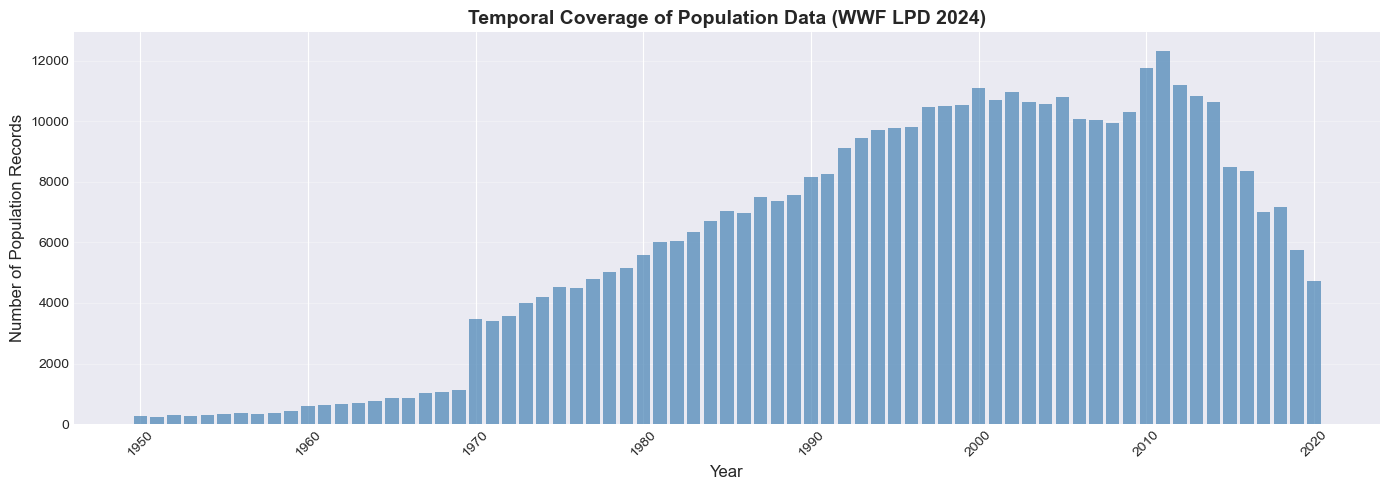

Data availability peaks in recent decades with trend toward more complete coverage


In [97]:
# Visualize temporal coverage 
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(temporal_coverage['Year'].astype(int), temporal_coverage['Count'], color='steelblue', alpha=0.7)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Population Records', fontsize=12)
ax.set_title('Temporal Coverage of Population Data (WWF LPD 2024)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Data availability peaks in recent decades with trend toward more complete coverage")

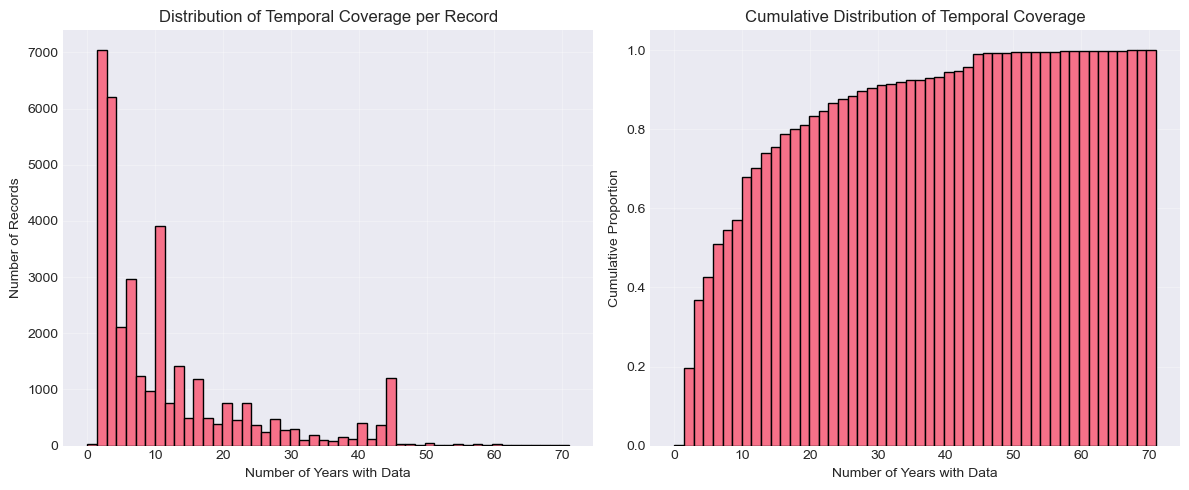

Temporal coverage statistics:
  Mean years per record: 11.7
  Median years per record: 7.0
  Min/Max years: 0 / 71

Records with at least:
  5 years: 22,734 (63.2%)
  10 years: 15,430 (42.9%)
  20 years: 6,779 (18.8%)
  30 years: 3,451 (9.6%)


In [98]:

# Time series coverage per species/record
# Calculate how many years of data each record has
year_data = df[year_cols_sorted]

# Number of non-null observations per record
obs_per_record = year_data.notna().sum(axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(obs_per_record, bins=50, edgecolor='black')
plt.xlabel('Number of Years with Data')
plt.ylabel('Number of Records')
plt.title('Distribution of Temporal Coverage per Record')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(obs_per_record, bins=50, edgecolor='black', cumulative=True, density=True)
plt.xlabel('Number of Years with Data')
plt.ylabel('Cumulative Proportion')
plt.title('Cumulative Distribution of Temporal Coverage')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Temporal coverage statistics:")
print(f"  Mean years per record: {obs_per_record.mean():.1f}")
print(f"  Median years per record: {obs_per_record.median():.1f}")
print(f"  Min/Max years: {obs_per_record.min()} / {obs_per_record.max()}")
print(f"\nRecords with at least:")
for threshold in [5, 10, 20, 30]:
    count = (obs_per_record >= threshold).sum()
    print(f"  {threshold} years: {count:,} ({count/len(df)*100:.1f}%)")

Records with data per decade:
  1950s: 602 (1.7%)
  1960s: 1,637 (4.5%)
  1970s: 7,229 (20.1%)
  1980s: 11,693 (32.5%)
  1990s: 19,209 (53.4%)
  2000s: 21,729 (60.4%)
  2010s: 18,992 (52.8%)
  2020s: 4,723 (13.1%)


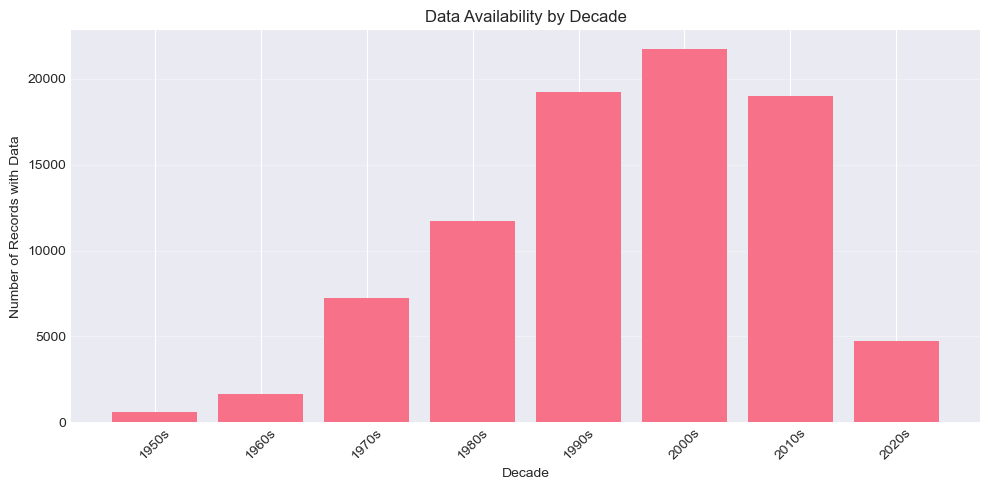

In [99]:
# Data availability by decade
decades = {
    '1950s': [str(y) for y in range(1950, 1960) if str(y) in year_cols_sorted],
    '1960s': [str(y) for y in range(1960, 1970) if str(y) in year_cols_sorted],
    '1970s': [str(y) for y in range(1970, 1980) if str(y) in year_cols_sorted],
    '1980s': [str(y) for y in range(1980, 1990) if str(y) in year_cols_sorted],
    '1990s': [str(y) for y in range(1990, 2000) if str(y) in year_cols_sorted],
    '2000s': [str(y) for y in range(2000, 2010) if str(y) in year_cols_sorted],
    '2010s': [str(y) for y in range(2010, 2020) if str(y) in year_cols_sorted],
    '2020s': [str(y) for y in range(2020, 2030) if str(y) in year_cols_sorted],
}

decade_coverage = {}
for decade, years in decades.items():
    if years:
        # Count records with at least one observation in this decade
        has_data = df[years].notna().any(axis=1).sum()
        decade_coverage[decade] = has_data

print("Records with data per decade:")
for decade, count in decade_coverage.items():
    print(f"  {decade}: {count:,} ({count/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.bar(decade_coverage.keys(), decade_coverage.values())
plt.xlabel('Decade')
plt.ylabel('Number of Records with Data')
plt.title('Data Availability by Decade')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [111]:
# Time series trends - aggregate statistics per year
print("\nYear-by-Year Population Statistics:")
print("-" * 80)

yearly_stats = []
for year in sorted(year_cols):
    values = df[year].dropna()
    if len(values) > 0:
        yearly_stats.append({
            'Year': int(year),
            'Count': len(values),
            'Mean': values.mean(),
            'Median': values.median(),
            'Std': values.std(),
            'Min': values.min(),
            'Max': values.max()
        })

yearly_df = pd.DataFrame(yearly_stats)
print(yearly_df.to_string(index=False))


Year-by-Year Population Statistics:
--------------------------------------------------------------------------------
 Year  Count         Mean     Median          Std  Min          Max
 1950    265 9.441820e+12 243.000000 1.535733e+14  0.0 2.500000e+15
 1951    245 1.004931e+13 353.000000 1.571631e+14  0.0 2.460000e+15
 1952    290 8.351971e+12 281.500000 1.421069e+14  0.0 2.420000e+15
 1953    285 8.287969e+12 294.000000 1.397940e+14  0.0 2.360000e+15
 1954    303 7.597560e+12 323.000000 1.321312e+14  0.0 2.300000e+15
 1955    325 7.093693e+12 191.700000 1.237523e+14  0.0 2.230000e+15
 1956    371 5.991778e+12 300.000000 1.116729e+14  0.0 2.150000e+15
 1957    340 6.260409e+12 490.000000 1.117665e+14  0.0 2.060000e+15
 1958    382 5.324943e+12 295.500000 1.008355e+14  0.0 1.970000e+15
 1959    427 4.496528e+12 300.000000 9.004869e+13  0.0 1.860000e+15
 1960    607 2.974806e+12 350.000000 7.106005e+13  0.0 1.750000e+15
 1961    648 2.593822e+12 458.500000 6.405810e+13  0.0 1.630000e+1

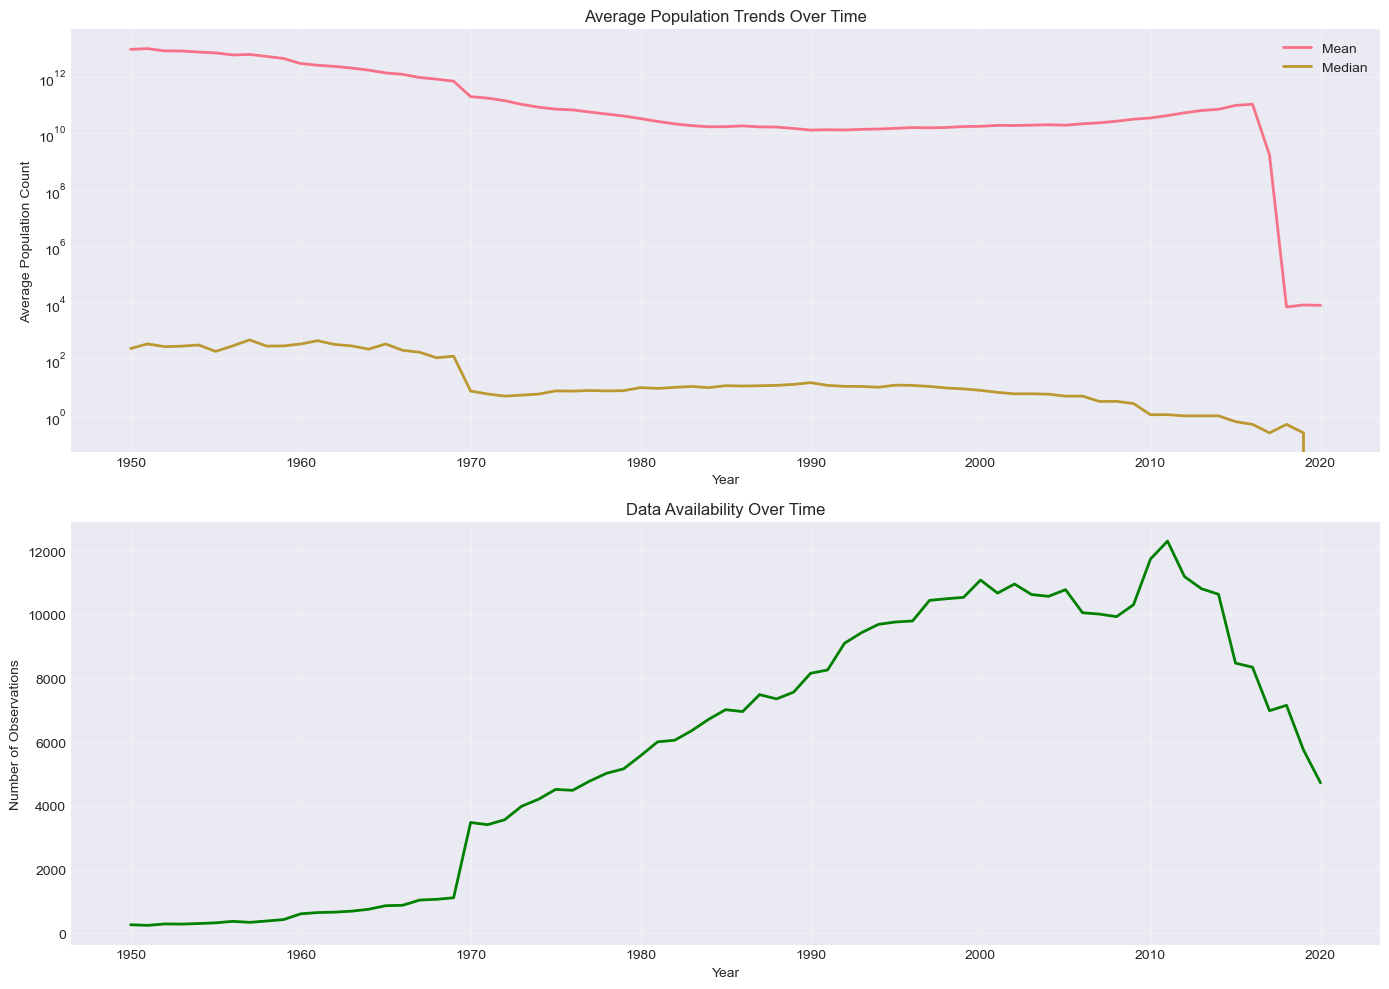

In [112]:
# Average trends over time
yearly_means = []
yearly_medians = []
yearly_counts = []

for year in year_cols_sorted:
    data = df[year].dropna()
    if len(data) > 0:
        yearly_means.append(data.mean())
        yearly_medians.append(data.median())
        yearly_counts.append(len(data))
    else:
        yearly_means.append(np.nan)
        yearly_medians.append(np.nan)
        yearly_counts.append(0)

years_int = [int(y) for y in year_cols_sorted]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Mean and median trends
axes[0].plot(years_int, yearly_means, label='Mean', linewidth=2)
axes[0].plot(years_int, yearly_medians, label='Median', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Population Count')
axes[0].set_title('Average Population Trends Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Number of observations per year
axes[1].plot(years_int, yearly_counts, linewidth=2, color='green')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Observations')
axes[1].set_title('Data Availability Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

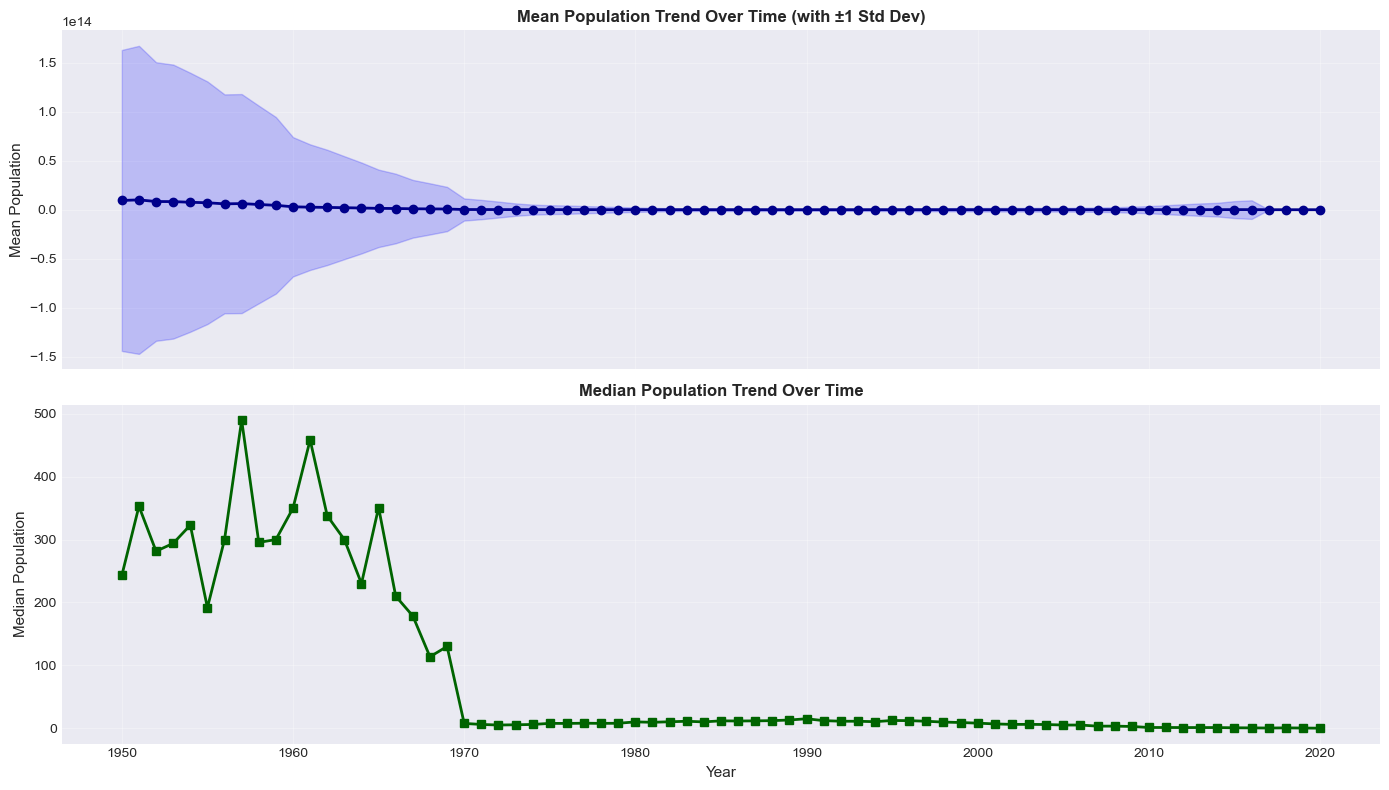

In [113]:
# Trends visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Mean population over time
axes[0].plot(yearly_df['Year'], yearly_df['Mean'], marker='o', linewidth=2, markersize=6, color='darkblue')
axes[0].fill_between(yearly_df['Year'], 
                      yearly_df['Mean'] - yearly_df['Std'], 
                      yearly_df['Mean'] + yearly_df['Std'], 
                      alpha=0.2, color='blue')
axes[0].set_ylabel('Mean Population', fontsize=11)
axes[0].set_title('Mean Population Trend Over Time (with ±1 Std Dev)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticklabels([])

# Median population over time
axes[1].plot(yearly_df['Year'], yearly_df['Median'], marker='s', linewidth=2, markersize=6, color='darkgreen')
axes[1].set_ylabel('Median Population', fontsize=11)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_title('Median Population Trend Over Time', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 - STATISTICAL TRENDS

Total observations: 420,356

Population count statistics:
  Mean: 1.17e+11
  Median: 5.00e+00
  Std: 1.31e+13
  Min: 0.00e+00
  Max: 2.50e+15
  Std Dev: 1.31e+13
  Zero counts: 62,002 (14.7%)
  Negative counts: 0 (0.0%)

Log10(Population Count) statistics (positive counts only):
  Mean: 1.28
  Median: 1.07
  Std: 1.84
  Min: -6.77
  Max: 15.40


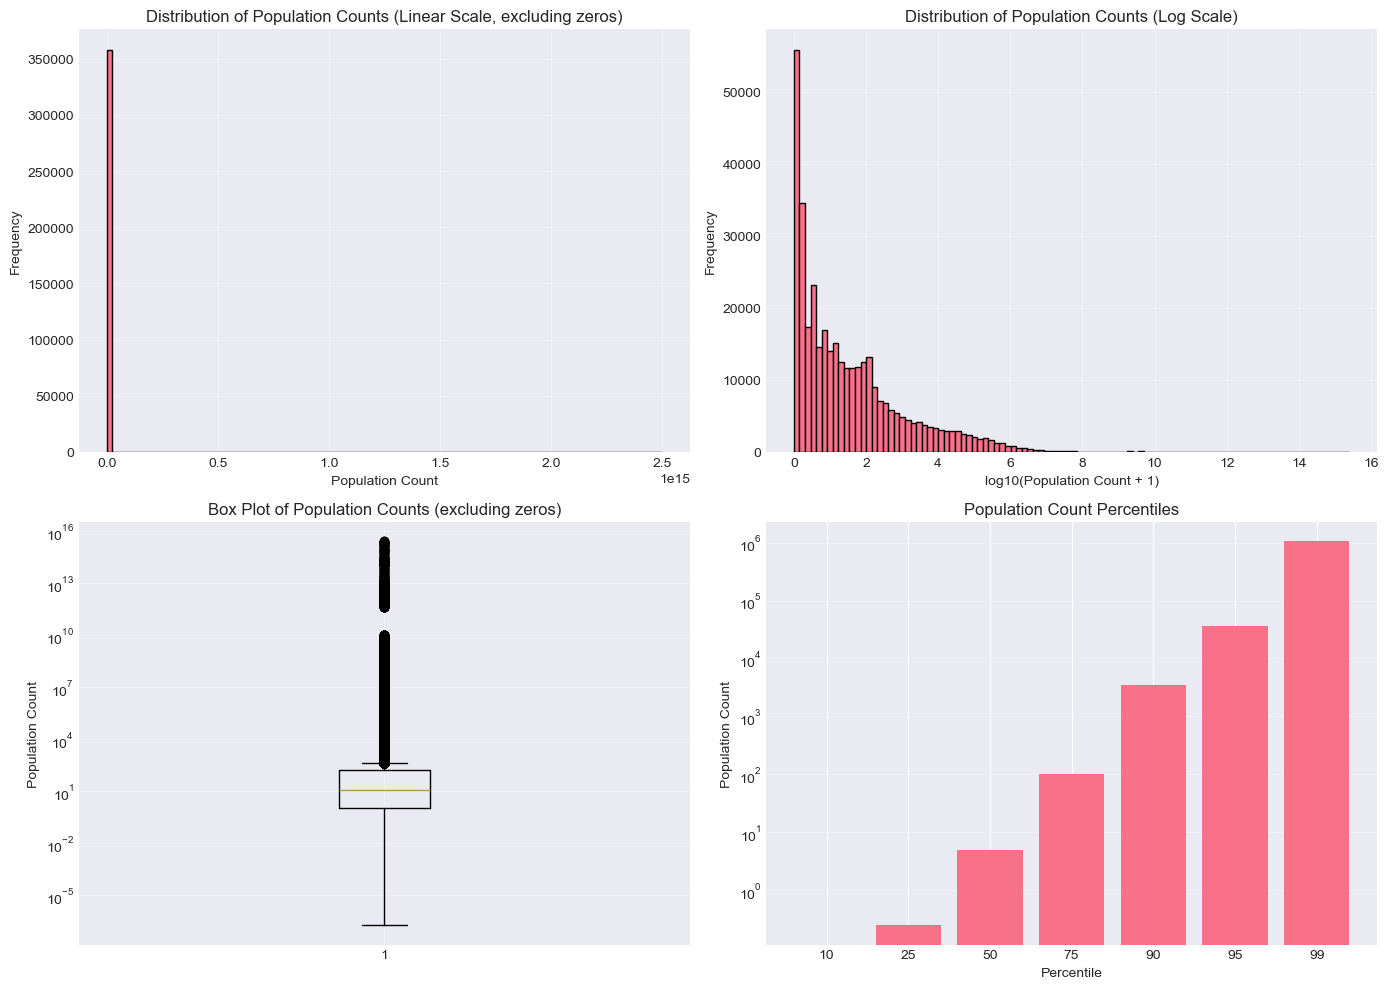

In [107]:
# Distribution of population counts
# Get all non-null values from year columns
all_counts = year_data.values.flatten()
all_counts = all_counts[~np.isnan(all_counts)]

print(f"Total observations: {len(all_counts):,}")
print(f"\nPopulation count statistics:")
print(f"  Mean: {all_counts.mean():.2e}")
print(f"  Median: {np.median(all_counts):.2e}")
print(f"  Std: {all_counts.std():.2e}")
print(f"  Min: {all_counts.min():.2e}")
print(f"  Max: {all_counts.max():.2e}")
print(f"  Std Dev: {all_counts.std():.2e}")
print(f"  Zero counts: {(all_counts == 0).sum():,} ({(all_counts == 0).sum()/len(all_counts)*100:.1f}%)")
negative_counts = (all_counts < 0).sum()
print(f"  Negative counts: {negative_counts:,} ({negative_counts/len(all_counts)*100:.1f}%)")


# Log-scale statistics (common for population data)
log_counts = np.log10(all_counts[all_counts > 0])  # Only consider positive counts for log scale
print(f"\nLog10(Population Count) statistics (positive counts only):")
print(f"  Mean: {log_counts.mean():.2f}")
print(f"  Median: {np.median(log_counts):.2f}")
print(f"  Std: {log_counts.std():.2f}")
print(f"  Min: {log_counts.min():.2f}")
print(f"  Max: {log_counts.max():.2f}")

# Distribution on log scale
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear scale
axes[0, 0].hist(all_counts[all_counts > 0], bins=100, edgecolor='black')
axes[0, 0].set_xlabel('Population Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Population Counts (Linear Scale, excluding zeros)')
axes[0, 0].grid(True, alpha=0.3)

# Log scale
axes[0, 1].hist(np.log10(all_counts[all_counts > 0] + 1), bins=100, edgecolor='black')
axes[0, 1].set_xlabel('log10(Population Count + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Population Counts (Log Scale)')
axes[0, 1].grid(True, alpha=0.3)

# Box plot by percentile
axes[1, 0].boxplot(all_counts[all_counts > 0], vert=True)
axes[1, 0].set_ylabel('Population Count')
axes[1, 0].set_title('Box Plot of Population Counts (excluding zeros)')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
pct_values = np.percentile(all_counts, percentiles)
axes[1, 1].bar([str(p) for p in percentiles], pct_values)
axes[1, 1].set_xlabel('Percentile')
axes[1, 1].set_ylabel('Population Count')
axes[1, 1].set_title('Population Count Percentiles')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

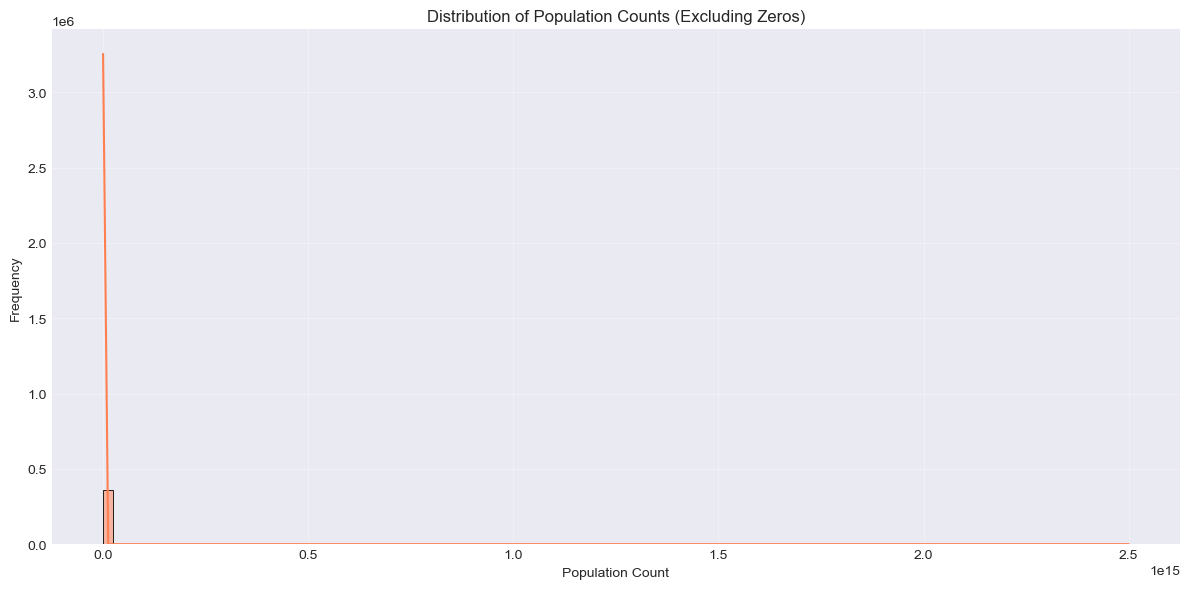

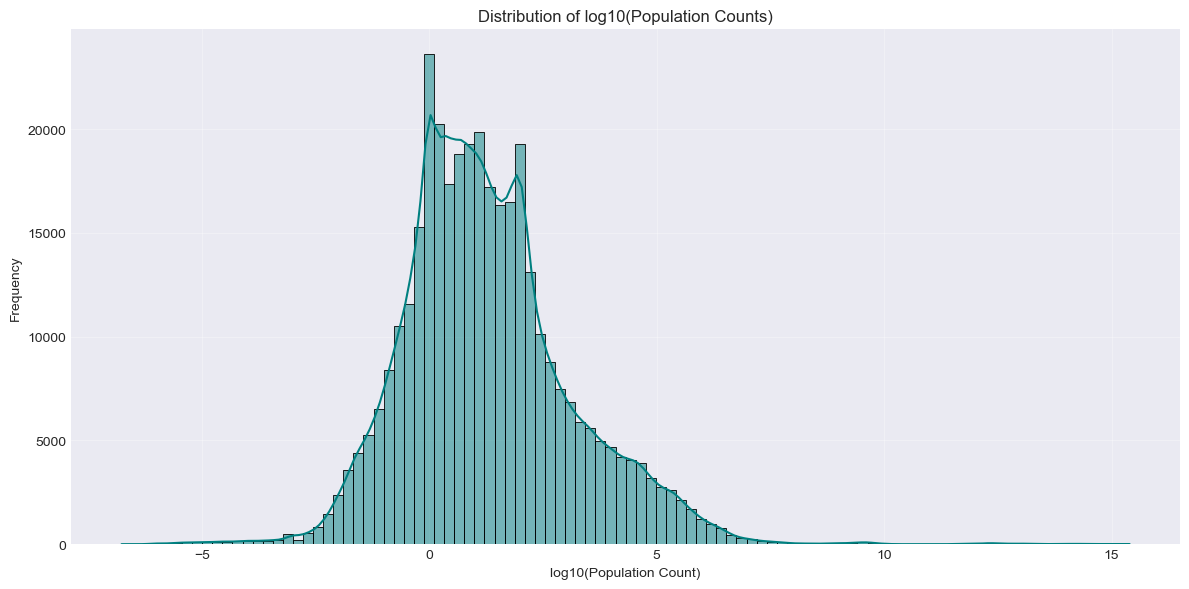

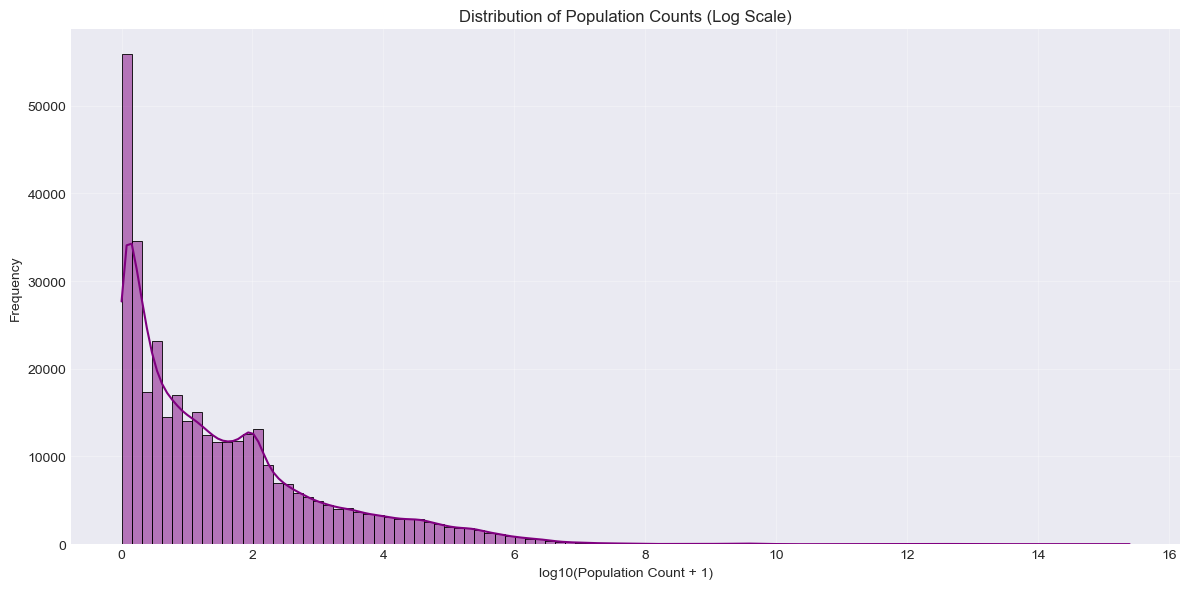

In [109]:
# Distribution of population values
plt.figure(figsize=(12, 6))
sns.histplot(all_counts[all_counts > 0], bins=100, kde=True,
                color='coral', edgecolor='black')
plt.xlabel('Population Count')
plt.ylabel('Frequency')
plt.title('Distribution of Population Counts (Excluding Zeros)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(log_counts, bins=100, kde=True,
                color='teal', edgecolor='black')
plt.xlabel('log10(Population Count)')
plt.ylabel('Frequency')
plt.title('Distribution of log10(Population Counts)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Log-scale histogram (for positive counts only)
plt.figure(figsize=(12, 6))
sns.histplot(np.log10(all_counts[all_counts > 0] + 1), bins=100, kde=True,
                color='purple', edgecolor='black')
plt.xlabel('log10(Population Count + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of Population Counts (Log Scale)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Population values span multiple orders of magnitude, suggesting log-scale transformation may be beneficial for forecasting.

---
# **6 - TIME SERIES IN DEPTH**

### 6.1 - QUALITY ASSESSMENT

Time Series Quality Metrics:

Gaps (missing years within time series):
count    35996.000000
mean         4.573953
std          7.577802
min          0.000000
25%          0.000000
50%          1.000000
75%          6.000000
max         53.000000
Name: num_gaps, dtype: float64

Time span (years from first to last observation):
count    35996.000000
mean        16.251806
std         12.652486
min          0.000000
25%          6.000000
50%         12.000000
75%         23.000000
max         71.000000
Name: time_span, dtype: float64

Continuity ratio (observations / span):
count    35980.000000
mean         0.745107
std          0.314243
min          0.040000
25%          0.500000
50%          0.958333
75%          1.000000
max          1.000000
Name: continuity_ratio, dtype: float64


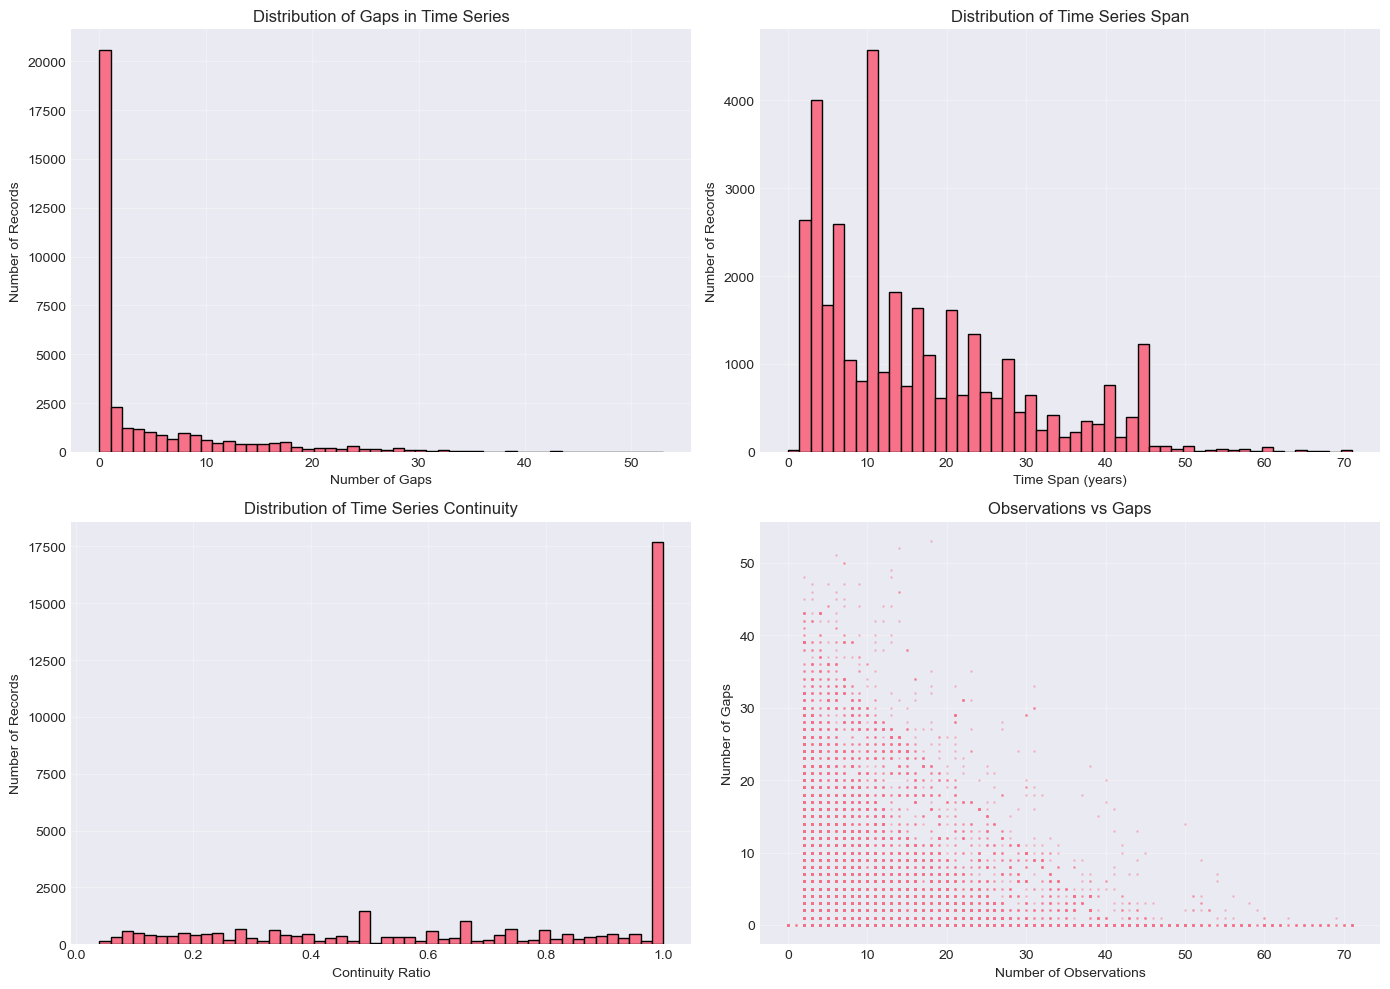


Records with perfect continuity (no gaps): 17,711 (49.2%)
Records with >50% continuity: 26,104 (72.5%)


In [ ]:
# Continuity of time series (gaps analysis)
def calculate_gaps(row):
    """Calculate the number of gaps in a time series"""
    values = row[year_cols_sorted]
    non_null_indices = np.where(values.notna())[0]
    
    if len(non_null_indices) <= 1:
        return 0
    
    # Gap is when there are missing values between first and last observation
    first_idx = non_null_indices[0]
    last_idx = non_null_indices[-1]
    expected_obs = last_idx - first_idx + 1
    actual_obs = len(non_null_indices)
    gaps = expected_obs - actual_obs
    
    return gaps

# Calculate gaps for each record
df['num_gaps'] = df.apply(calculate_gaps, axis=1)
df['num_observations'] = obs_per_record

# Calculate time span (years between first and last observation)
def calculate_span(row):
    values = row[year_cols_sorted]
    non_null_indices = np.where(values.notna())[0]
    
    if len(non_null_indices) == 0:
        return 0
    
    first_year = int(year_cols_sorted[non_null_indices[0]])
    last_year = int(year_cols_sorted[non_null_indices[-1]])
    
    return last_year - first_year + 1

df['time_span'] = df.apply(calculate_span, axis=1)

# Continuity ratio (observations / span)
df['continuity_ratio'] = df['num_observations'] / df['time_span'].replace(0, np.nan)

print("Time Series Quality Metrics:")
print(f"\nGaps (missing years within time series):")
print(df['num_gaps'].describe())

print(f"\nTime span (years from first to last observation):")
print(df['time_span'].describe())

print(f"\nContinuity ratio (observations / span):")
print(df['continuity_ratio'].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gaps distribution
axes[0, 0].hist(df['num_gaps'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Number of Gaps')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].set_title('Distribution of Gaps in Time Series')
axes[0, 0].grid(True, alpha=0.3)

# Time span distribution
axes[0, 1].hist(df['time_span'], bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Time Span (years)')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_title('Distribution of Time Series Span')
axes[0, 1].grid(True, alpha=0.3)

# Continuity ratio
axes[1, 0].hist(df['continuity_ratio'].dropna(), bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Continuity Ratio')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_title('Distribution of Time Series Continuity')
axes[1, 0].grid(True, alpha=0.3)

# Scatter: observations vs gaps
axes[1, 1].scatter(df['num_observations'], df['num_gaps'], alpha=0.3, s=1)
axes[1, 1].set_xlabel('Number of Observations')
axes[1, 1].set_ylabel('Number of Gaps')
axes[1, 1].set_title('Observations vs Gaps')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [119]:
# Records with perfect continuity
print(f"\nRecords with perfect continuity (no gaps): {(df['num_gaps'] == 0).sum():,} ({(df['num_gaps'] == 0).sum()/len(df)*100:.1f}%)")

# Records with >50% continuity
print(f"\nRecords with >50% continuity: {(df['continuity_ratio'] > 0.5).sum():,} ({(df['continuity_ratio'] > 0.5).sum()/len(df)*100:.1f}%)")

# Records with perfect continuity (no gaps) - at least 20 years continuously
perfect_continuity = df[(df['num_gaps'] == 0) & (df['time_span'] >= 20)]
print(f"\nRecords with perfect continuity and at least 20 years span: {len(perfect_continuity):,} ({len(perfect_continuity)/len(df)*100:.1f}%)")    

# Records with perfect continuity (no gaps) - at least 20 years continuously reaching 2020
perfect_continuity_recent = df[(df['num_gaps'] == 0) & (df['time_span'] >= 20) & (df['time_span'] + df[year_cols_sorted].apply(lambda x: x.first_valid_index(), axis=1).fillna(0).astype(int) >= 2020)]
print(f"\nRecords with perfect continuity, at least 20 years span, and reaching 2020: {len(perfect_continuity_recent):,} ({len(perfect_continuity_recent)/len(df)*100:.1f}%)")


Records with perfect continuity (no gaps): 17,711 (49.2%)

Records with >50% continuity: 26,104 (72.5%)

Records with perfect continuity and at least 20 years span: 5,041 (14.0%)

Records with perfect continuity, at least 20 years span, and reaching 2020: 690 (1.9%)


### 6.2 - POPULATION TRAJECTORIES EXAMPLES


Group 1 records (perfect continuity, >=20 years, reaching 2020): 594


c:\Users\Vaccari\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


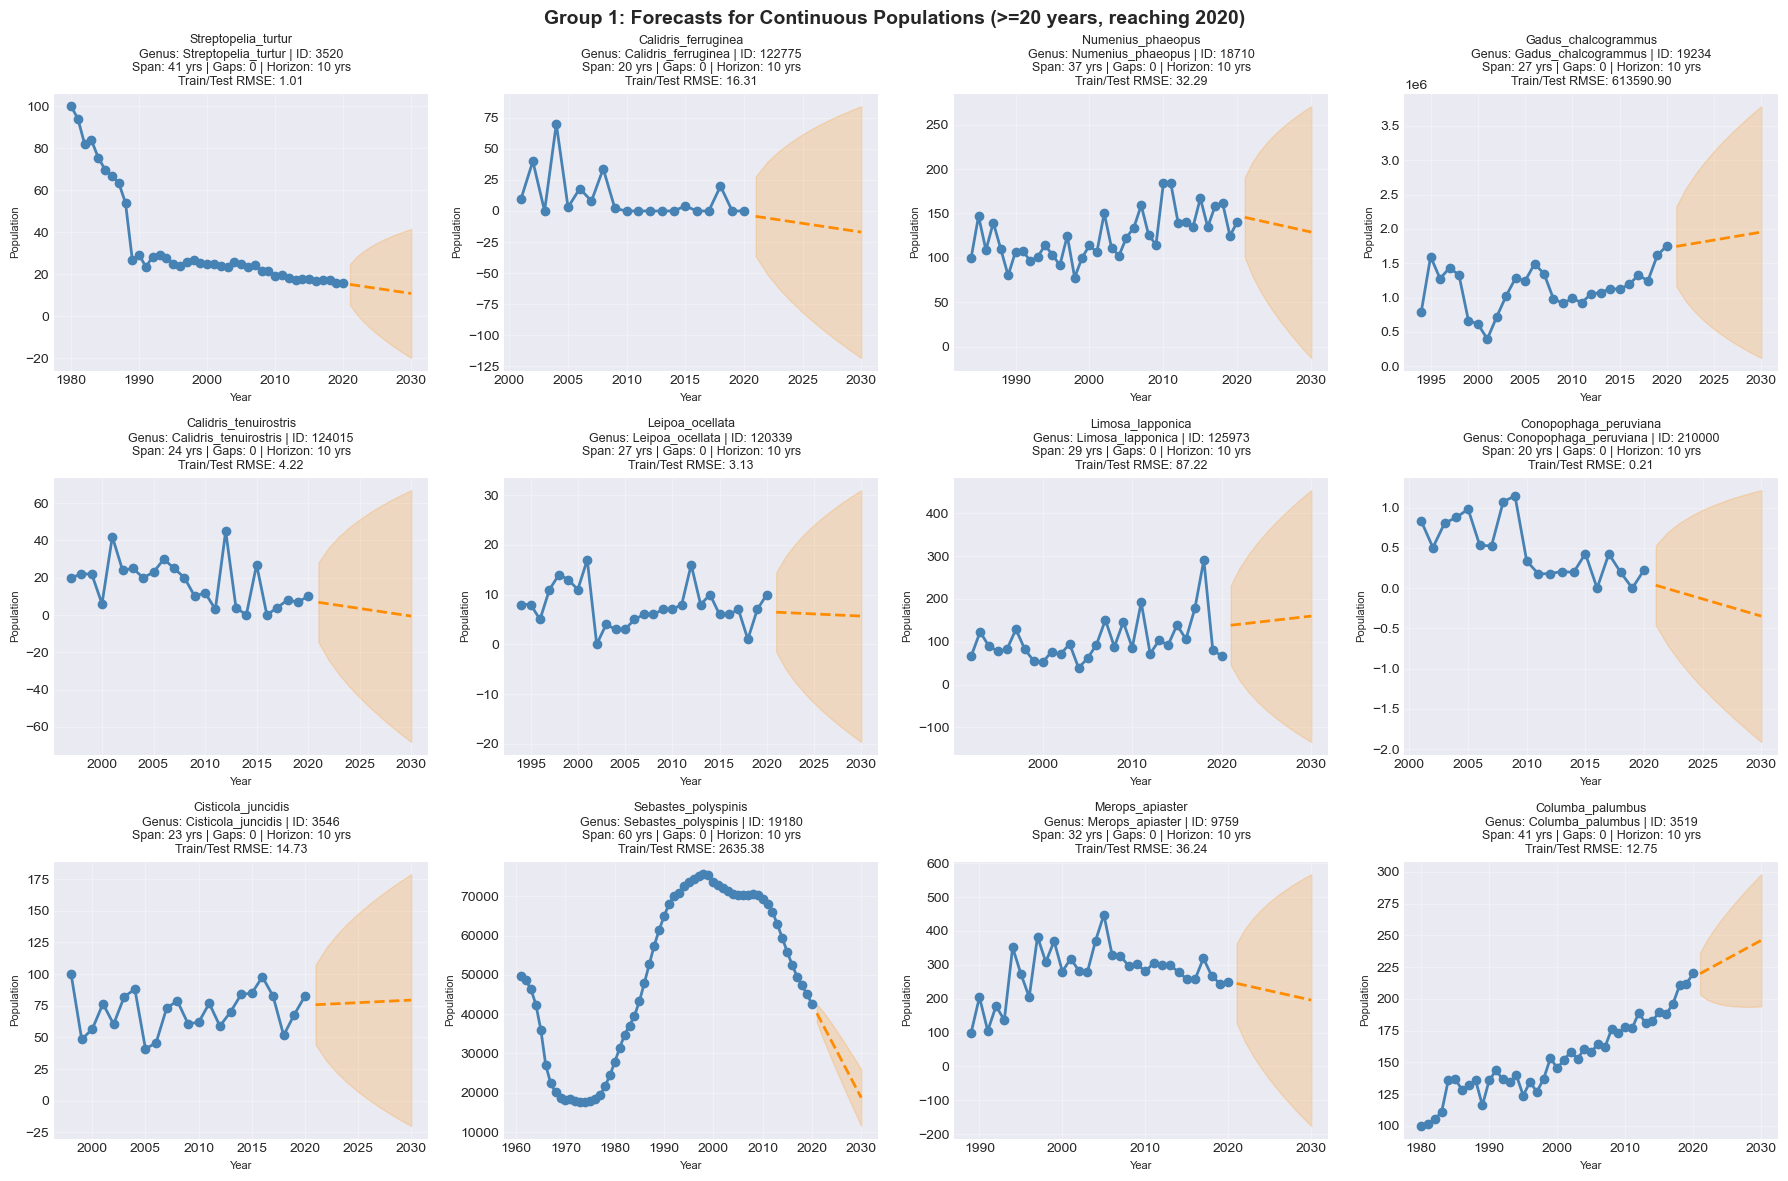


Group 1 evaluation summary:
        ID               Binomial  time_span  num_gaps            mae  \
0     3520    Streptopelia_turtur       41.0       0.0       0.896256   
1   122775    Calidris_ferruginea       20.0       0.0      13.996322   
2    18710      Numenius_phaeopus       37.0       0.0      28.109381   
3    19234    Gadus_chalcogrammus       27.0       0.0  528387.157944   
4   124015  Calidris_tenuirostris       24.0       0.0       3.452615   
5   120339        Leipoa_ocellata       27.0       0.0       2.179560   
6   125973       Limosa_lapponica       29.0       0.0      67.739191   
7   210000  Conopophaga_peruviana       20.0       0.0       0.176093   
8     3546     Cisticola_juncidis       23.0       0.0      11.385328   
9    19180    Sebastes_polyspinis       60.0       0.0    2131.694537   
10    9759        Merops_apiaster       32.0       0.0      28.012587   
11    3519       Columba_palumbus       41.0       0.0      10.820553   

             rmse    

c:\Users\Vaccari\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Vaccari\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


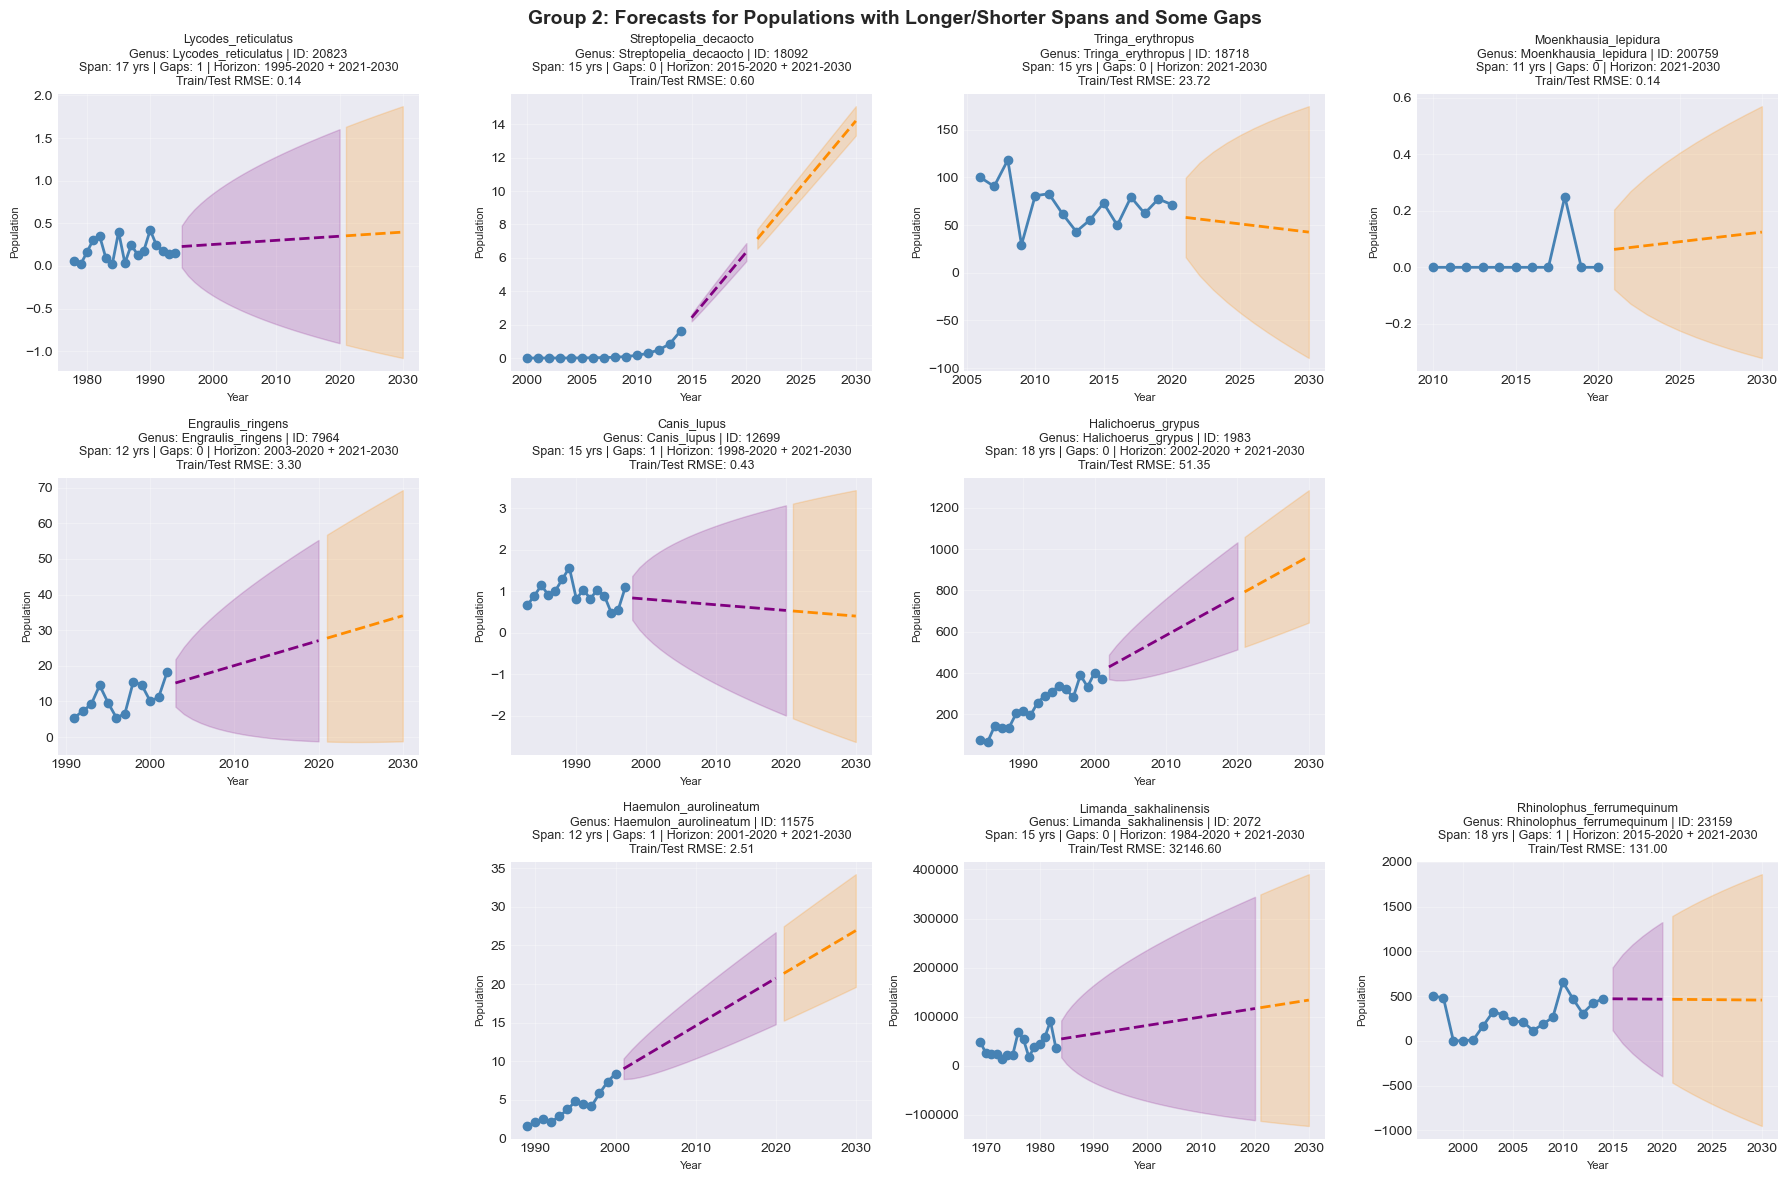


Group 2 evaluation summary:
       ID                   Binomial  time_span  num_gaps  max_gap  last_year  \
0   20823        Lycodes_reticulatus       17.0       1.0      1.0     1994.0   
1   18092      Streptopelia_decaocto       15.0       0.0      0.0     2014.0   
2   18718          Tringa_erythropus       15.0       0.0      0.0     2020.0   
3  200759       Moenkhausia_lepidura       11.0       0.0      0.0     2020.0   
4    7964          Engraulis_ringens       12.0       0.0      0.0     2002.0   
5   12699                Canis_lupus       15.0       1.0      1.0     1997.0   
6    1983         Halichoerus_grypus       18.0       0.0      0.0     2001.0   
7   11575      Haemulon_aurolineatum       12.0       1.0      1.0     2000.0   
8    2072      Limanda_sakhalinensis       15.0       0.0      0.0     1983.0   
9   23159  Rhinolophus_ferrumequinum       18.0       1.0      1.0     2014.0   

            mae          rmse        mape  
0      0.135047      0.136623   87.

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 0. PREPARE DATA
# =========================================================

# Make sure year columns are sorted
year_cols_sorted = sorted(year_cols, key=int)
years_int = [int(y) for y in year_cols_sorted]

# Count number of years with data
df["n_years_with_data"] = df[year_cols_sorted].notna().sum(axis=1)

# First and last valid year
df["first_year"] = df[year_cols_sorted].apply(lambda row: row.first_valid_index(), axis=1)
df["last_year"] = df[year_cols_sorted].apply(lambda row: row.last_valid_index(), axis=1)

# Convert to numeric where possible
df["first_year"] = pd.to_numeric(df["first_year"], errors="coerce")
df["last_year"] = pd.to_numeric(df["last_year"], errors="coerce")

# Time span = last year - first year + 1
df["time_span"] = df["last_year"] - df["first_year"] + 1

# Function to count number of missing years between first and last observation
def count_internal_gaps(row):
    if pd.isna(row["first_year"]) or pd.isna(row["last_year"]):
        return np.nan
    cols_in_span = [str(y) for y in range(int(row["first_year"]), int(row["last_year"]) + 1) if str(y) in year_cols_sorted]
    return row[cols_in_span].isna().sum()

# Function to compute maximum consecutive gap
def max_consecutive_gaps(row):
    if pd.isna(row["first_year"]) or pd.isna(row["last_year"]):
        return np.nan
    cols_in_span = [str(y) for y in range(int(row["first_year"]), int(row["last_year"]) + 1) if str(y) in year_cols_sorted]
    gaps = row[cols_in_span].isna().astype(int).values

    max_gap = 0
    current_gap = 0
    for g in gaps:
        if g == 1:
            current_gap += 1
            max_gap = max(max_gap, current_gap)
        else:
            current_gap = 0
    return max_gap

df["num_gaps"] = df.apply(count_internal_gaps, axis=1)
df["max_gap"] = df.apply(max_consecutive_gaps, axis=1)

# =========================================================
# 1. HELPER FUNCTIONS
# =========================================================

def get_species_label(row):
    binomial = row.get("Binomial", "Unknown species")
    genus = binomial.split()[0] if isinstance(binomial, str) and len(binomial.split()) > 0 else "Unknown"
    pop_id = row.get("ID", "NA")
    return f"{binomial}\nGenus: {genus} | ID: {pop_id}"

def extract_series(row):
    """
    Return observed years and values only (dropping NaNs).
    """
    vals = row[year_cols_sorted]
    mask = vals.notna()
    years = np.array([int(y) for y in year_cols_sorted])[mask.values]
    values = vals[mask].astype(float).values
    return years, values

def make_regular_series(row, end_year=None, interpolate_internal=True):
    """
    Create a regular yearly series from first_year to end_year (or last observed year).
    Internal gaps can be linearly interpolated.
    """
    years_obs, values_obs = extract_series(row)
    if len(years_obs) < 2:
        return None, None

    start = int(years_obs.min())
    stop = int(end_year) if end_year is not None else int(years_obs.max())

    full_years = np.arange(start, stop + 1)
    s = pd.Series(index=full_years, dtype=float)
    s.loc[years_obs] = values_obs

    if interpolate_internal:
        s = s.interpolate(method="linear", limit_area="inside")

    return full_years, s.values

def chronological_split(values, min_train=10, test_size=5):
    """
    Chronological train/test split.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)

    if n < (min_train + 3):
        return None, None

    test_size = min(test_size, max(3, n // 5))
    train_size = n - test_size

    if train_size < min_train:
        return None, None

    train = values[:train_size]
    test = values[train_size:]
    return train, test

def fit_hw_and_forecast(train, horizon):
    """
    Fit additive Holt model and forecast.
    Return forecast + approximate widening uncertainty bands.
    """
    try:
        model = ExponentialSmoothing(train, trend="add", seasonal=None, initialization_method="estimated")
        fit = model.fit(optimized=True)

        forecast = fit.forecast(horizon)

        # Residual-based uncertainty; widening with sqrt(h)
        resid = np.asarray(fit.fittedvalues) - np.asarray(train)
        resid_std = np.nanstd(resid, ddof=1) if len(resid) > 1 else np.nanstd(train)

        if np.isnan(resid_std) or resid_std == 0:
            resid_std = max(1e-6, np.nanstd(train) * 0.1 + 1e-6)

        horizon_index = np.arange(1, horizon + 1)
        band = 1.96 * resid_std * np.sqrt(horizon_index)

        lower = forecast - band
        upper = forecast + band

        return fit, np.asarray(forecast), np.asarray(lower), np.asarray(upper)

    except Exception:
        return None, None, None, None

def evaluate_forecast(train, test):
    """
    Fit on train, forecast test horizon, compute metrics.
    """
    fit, pred, _, _ = fit_hw_and_forecast(train, len(test))
    if pred is None:
        return None

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))

    # avoid division by zero in MAPE
    nonzero_mask = np.array(test) != 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((np.array(test)[nonzero_mask] - pred[nonzero_mask]) / np.array(test)[nonzero_mask])) * 100
    else:
        mape = np.nan

    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape
    }

# =========================================================
# 2. GROUP 1:
# perfect continuity, >=20 years, must reach 2020
# forecast 2021-2030
# =========================================================

group1 = df[
    (df["num_gaps"] == 0) &
    (df["time_span"] >= 20) &
    (df["last_year"] >= 2020)
].copy()

print(f"\nGroup 1 records (perfect continuity, >=20 years, reaching 2020): {len(group1)}")

if len(group1) > 0:
    n1 = min(12, len(group1))
    group1_sample = group1.sample(n=n1, random_state=42)

    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.flatten()

    results_group1 = []

    for ax, (_, row) in zip(axes, group1_sample.iterrows()):

        # use data only up to 2020 for model fitting/validation
        model_years, model_values = make_regular_series(row, end_year=2020, interpolate_internal=False)

        if model_years is None or len(model_values) < 20:
            ax.axis("off")
            continue

        train, test = chronological_split(model_values, min_train=10, test_size=5)
        if train is None:
            ax.axis("off")
            continue

        metrics = evaluate_forecast(train, test)

        # fit on full series up to 2020, forecast 2021-2030
        fit, forecast, lower, upper = fit_hw_and_forecast(model_values, 10)
        if forecast is None:
            ax.axis("off")
            continue

        forecast_years = np.arange(2021, 2031)

        # plot observed data
        ax.plot(model_years, model_values, marker="o", linewidth=2, color="steelblue", label="Observed")

        # plot forecast
        ax.plot(forecast_years, forecast, linestyle="--", linewidth=2, color="darkorange", label="Forecast")
        ax.fill_between(forecast_years, lower, upper, color="darkorange", alpha=0.2, label="95% CI")

        label = get_species_label(row)
        subtitle = (
            f"Span: {int(row['time_span'])} yrs | Gaps: {int(row['num_gaps'])} | Horizon: 10 yrs\n"
            f"Train/Test RMSE: {metrics['rmse']:.2f}" if metrics is not None else
            f"Span: {int(row['time_span'])} yrs | Gaps: {int(row['num_gaps'])} | Horizon: 10 yrs"
        )

        ax.set_title(f"{label}\n{subtitle}", fontsize=9)
        ax.set_xlabel("Year", fontsize=8)
        ax.set_ylabel("Population", fontsize=8)
        ax.grid(alpha=0.3)

        results_group1.append({
            "ID": row.get("ID", np.nan),
            "Binomial": row.get("Binomial", np.nan),
            "time_span": row.get("time_span", np.nan),
            "num_gaps": row.get("num_gaps", np.nan),
            "rmse": metrics["rmse"] if metrics is not None else np.nan,
            "mae": metrics["mae"] if metrics is not None else np.nan,
            "mape": metrics["mape"] if metrics is not None else np.nan
        })

    # turn off any unused axes
    for i in range(len(group1_sample), len(axes)):
        axes[i].axis("off")

    plt.suptitle("Group 1: Forecasts for Continuous Populations (>=20 years, reaching 2020)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nGroup 1 evaluation summary:")
    print(pd.DataFrame(results_group1)[["ID", "Binomial", "time_span", "num_gaps", "mae", "rmse", "mape"]])

else:
    print("No suitable records found for Group 1.")

# =========================================================
# 3. GROUP 2:
# random populations with either very long spans (>=40)
# or shorter spans (<20 but >=10), with up to 5 gaps,
# not necessarily reaching 2020
#
# Forecast from 2020 to 2030
# - last observation to 2020 highlighted with one color
# - 2020 to 2030 forecast with another color
# =========================================================

group2 = df[
    (
        (df["time_span"] >= 40) |
        ((df["time_span"] >= 10) & (df["time_span"] < 20))
    ) &
    (df["max_gap"] <= 5) &
    (df["n_years_with_data"] >= 10) &
    (df["first_year"].notna())
].copy()

print(f"\nGroup 2 records (>=40 yrs OR 10-19 yrs, max gap <=5): {len(group2)}")

if len(group2) > 0:
    n2 = min(12, len(group2))
    group2_sample = group2.sample(n=n2, random_state=123)

    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.flatten()

    results_group2 = []

    for ax, (_, row) in zip(axes, group2_sample.iterrows()):

        # Make regular series from first year to last observed year, interpolate internal gaps
        years_reg, values_reg = make_regular_series(row, end_year=int(row["last_year"]), interpolate_internal=True)

        if years_reg is None or len(values_reg) < 10:
            ax.axis("off")
            continue

        # Chronological split on observed history only
        train, test = chronological_split(values_reg, min_train=8, test_size=5)
        if train is None:
            ax.axis("off")
            continue

        metrics = evaluate_forecast(train, test)

        # Fit full model on history up to last observed year
        fit, forecast_to_2030, lower_to_2030, upper_to_2030 = fit_hw_and_forecast(
            values_reg,
            horizon=max(0, 2030 - int(row["last_year"]))
        )

        if forecast_to_2030 is None:
            ax.axis("off")
            continue

        last_obs_year = int(row["last_year"])
        future_years = np.arange(last_obs_year + 1, 2031)

        # observed history
        ax.plot(years_reg, values_reg, marker="o", linewidth=2, color="steelblue", label="Observed history")

        # section from last observation to 2020
        if last_obs_year < 2020:
            bridge_mask = future_years <= 2020
            bridge_years = future_years[bridge_mask]
            bridge_forecast = forecast_to_2030[:len(bridge_years)]
            bridge_lower = lower_to_2030[:len(bridge_years)]
            bridge_upper = upper_to_2030[:len(bridge_years)]

            if len(bridge_years) > 0:
                ax.plot(bridge_years, bridge_forecast, linestyle="--", linewidth=2, color="purple", label="Forecast to 2020")
                ax.fill_between(bridge_years, bridge_lower, bridge_upper, color="purple", alpha=0.18)

            # from 2021 to 2030
            after2020_mask = future_years > 2020
            after2020_years = future_years[after2020_mask]
            start_idx = len(bridge_years)
            after2020_forecast = forecast_to_2030[start_idx:]
            after2020_lower = lower_to_2030[start_idx:]
            after2020_upper = upper_to_2030[start_idx:]

            if len(after2020_years) > 0:
                ax.plot(after2020_years, after2020_forecast, linestyle="--", linewidth=2, color="darkorange", label="Forecast 2021-2030")
                ax.fill_between(after2020_years, after2020_lower, after2020_upper, color="darkorange", alpha=0.20)

        else:
            # already reaches 2020 or beyond
            forecast_years_2020_2030 = future_years[future_years >= 2020]
            start_idx = max(0, 2020 - (last_obs_year + 1))
            forecast_part = forecast_to_2030[start_idx:start_idx + len(forecast_years_2020_2030)]
            lower_part = lower_to_2030[start_idx:start_idx + len(forecast_years_2020_2030)]
            upper_part = upper_to_2030[start_idx:start_idx + len(forecast_years_2020_2030)]

            if len(forecast_years_2020_2030) > 0:
                ax.plot(forecast_years_2020_2030, forecast_part, linestyle="--", linewidth=2, color="darkorange", label="Forecast to 2030")
                ax.fill_between(forecast_years_2020_2030, lower_part, upper_part, color="darkorange", alpha=0.20)

        label = get_species_label(row)

        if last_obs_year < 2020:
            horizon_text = f"{last_obs_year+1}-2020 + 2021-2030"
        else:
            horizon_text = f"{last_obs_year+1}-2030"

        subtitle = (
            f"Span: {int(row['time_span'])} yrs | Gaps: {int(row['num_gaps'])} | Horizon: {horizon_text}\n"
            f"Train/Test RMSE: {metrics['rmse']:.2f}" if metrics is not None else
            f"Span: {int(row['time_span'])} yrs | Gaps: {int(row['num_gaps'])} | Horizon: {horizon_text}"
        )

        ax.set_title(f"{label}\n{subtitle}", fontsize=9)
        ax.set_xlabel("Year", fontsize=8)
        ax.set_ylabel("Population", fontsize=8)
        ax.grid(alpha=0.3)

        results_group2.append({
            "ID": row.get("ID", np.nan),
            "Binomial": row.get("Binomial", np.nan),
            "time_span": row.get("time_span", np.nan),
            "num_gaps": row.get("num_gaps", np.nan),
            "max_gap": row.get("max_gap", np.nan),
            "last_year": row.get("last_year", np.nan),
            "mae": metrics["mae"] if metrics is not None else np.nan,
            "rmse": metrics["rmse"] if metrics is not None else np.nan,
            "mape": metrics["mape"] if metrics is not None else np.nan
        })

    for i in range(len(group2_sample), len(axes)):
        axes[i].axis("off")

    plt.suptitle("Group 2: Forecasts for Populations with Longer/Shorter Spans and Some Gaps", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nGroup 2 evaluation summary:")
    print(pd.DataFrame(results_group2)[["ID", "Binomial", "time_span", "num_gaps", "max_gap", "last_year", "mae", "rmse", "mape"]])

else:
    print("No suitable records found for Group 2.")


Advanced exploratory forecasting records available: 6779


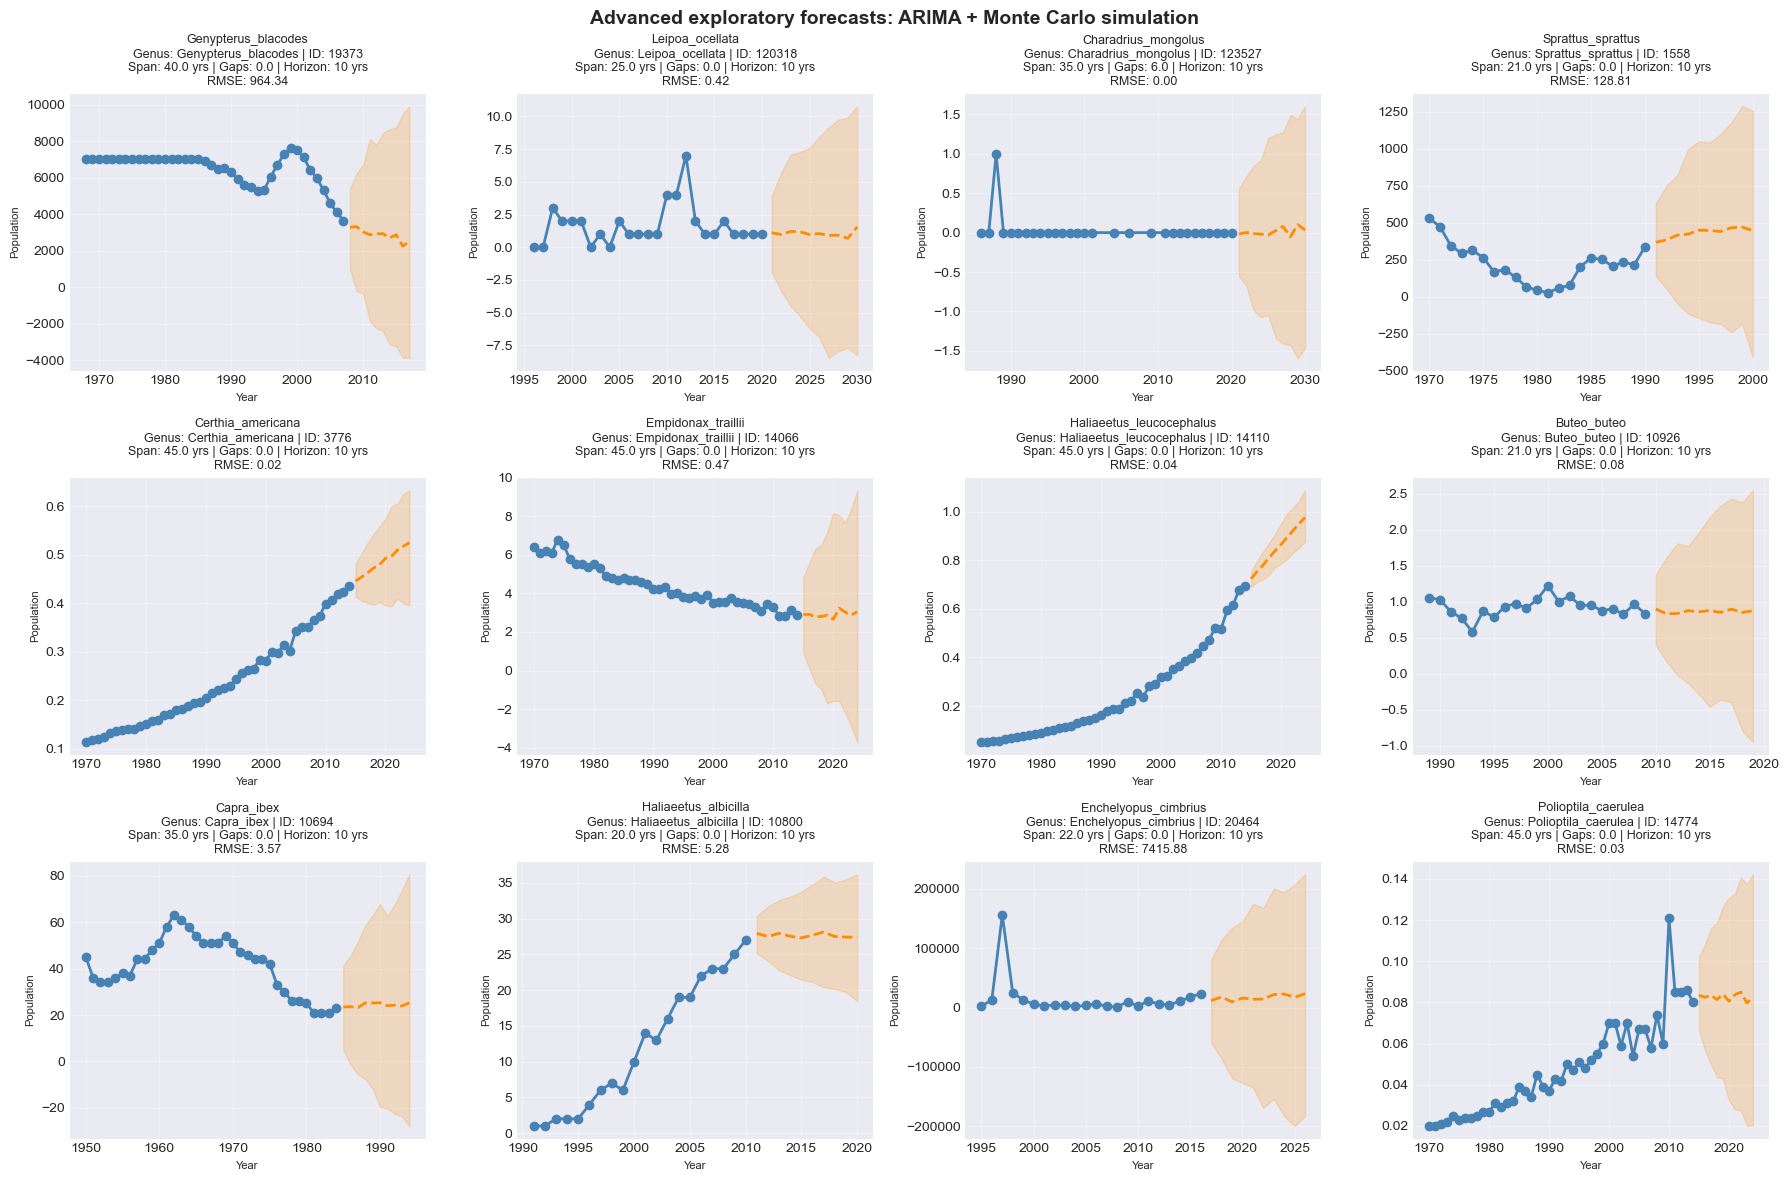


Advanced forecasting evaluation summary:
        ID                  Binomial  time_span  num_gaps           MAE  \
0    19373       Genypterus_blacodes       40.0       0.0  7.867209e+02   
1   120318           Leipoa_ocellata       25.0       0.0  2.199168e-01   
2   123527       Charadrius_mongolus       35.0       6.0  5.300607e-97   
3     1558         Sprattus_sprattus       21.0       0.0  1.201343e+02   
4     3776         Certhia_americana       45.0       0.0  2.047889e-02   
5    14066        Empidonax_traillii       45.0       0.0  4.324338e-01   
6    14110  Haliaeetus_leucocephalus       45.0       0.0  3.694613e-02   
7    10926               Buteo_buteo       21.0       0.0  7.245548e-02   
8    10694                Capra_ibex       35.0       0.0  3.229653e+00   
9    10800      Haliaeetus_albicilla       20.0       0.0  4.965197e+00   
10   20464      Enchelyopus_cimbrius       22.0       0.0  6.915207e+03   
11   14774       Polioptila_caerulea       45.0       0.0 

In [125]:
# =========================================================
# ADVANCED / EXPLORATORY FORECASTING EXTENSION
# ARIMA + Monte Carlo simulation
# This block is intended as a more flexible extension to the
# main forecasting analysis, allowing more variable trajectories.
# Forecasts should be interpreted as scenario-based projections,
# not precise predictions.
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------------
# Helper functions
# -----------------------------------------

def extract_observed_series(row, year_cols):
    values = row[year_cols]
    mask = values.notna()
    years = np.array([int(y) for y in year_cols])[mask.values]
    series = values[mask].astype(float).values
    return years, series

def chronological_split(series, test_size=5, min_train=10):
    n = len(series)
    if n < min_train + test_size:
        return None, None
    train = series[:-test_size]
    test = series[-test_size:]
    return train, test

def fit_arima_model(train_series, arima_order=(1, 1, 1)):
    try:
        model = ARIMA(train_series, order=arima_order)
        fit = model.fit()
        return fit
    except Exception:
        return None

def evaluate_arima(train_series, test_series, arima_order=(1, 1, 1)):
    fit = fit_arima_model(train_series, arima_order=arima_order)
    if fit is None:
        return None, None

    pred = fit.forecast(steps=len(test_series))

    mae = mean_absolute_error(test_series, pred)
    rmse = np.sqrt(mean_squared_error(test_series, pred))

    nonzero_mask = np.array(test_series) != 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(
            np.abs((np.array(test_series)[nonzero_mask] - pred[nonzero_mask]) / np.array(test_series)[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    return pred, {"MAE": mae, "RMSE": rmse, "MAPE": mape}

def monte_carlo_forecast_arima(full_series, horizon=10, n_simulations=500, arima_order=(1, 1, 1)):
    fit = fit_arima_model(full_series, arima_order=arima_order)
    if fit is None:
        return None, None, None, None

    base_forecast = fit.forecast(steps=horizon)

    # residual standard deviation
    residuals = fit.resid
    resid_std = np.nanstd(residuals, ddof=1)

    if np.isnan(resid_std) or resid_std == 0:
        resid_std = max(np.nanstd(full_series) * 0.1, 1e-6)

    simulations = []
    for _ in range(n_simulations):
        sim = []
        for h in range(horizon):
            # noise grows with forecast horizon
            noise = np.random.normal(0, resid_std * np.sqrt(h + 1))
            sim.append(base_forecast[h] + noise)
        simulations.append(sim)

    simulations = np.array(simulations)

    median_forecast = np.median(simulations, axis=0)
    lower_95 = np.percentile(simulations, 2.5, axis=0)
    upper_95 = np.percentile(simulations, 97.5, axis=0)

    return base_forecast, median_forecast, lower_95, upper_95

# -----------------------------------------
# Select records for exploratory forecasting
# Example: use the same "good quality" subset
# -----------------------------------------

advanced_records = df[
    (df["n_years_with_data"] >= 20) &
    (df["last_year"].notna())
].copy()

print(f"\nAdvanced exploratory forecasting records available: {len(advanced_records)}")

if len(advanced_records) > 0:
    n_sample = min(12, len(advanced_records))
    advanced_sample = advanced_records.sample(n=n_sample, random_state=42)

    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.flatten()

    advanced_results = []

    for ax, (_, row) in zip(axes, advanced_sample.iterrows()):
        years_obs, series_obs = extract_observed_series(row, year_cols_sorted)

        if len(series_obs) < 15:
            ax.axis("off")
            continue

        # chronological train/test split
        train, test = chronological_split(series_obs, test_size=5, min_train=10)
        if train is None:
            ax.axis("off")
            continue

        pred_test, metrics = evaluate_arima(train, test, arima_order=(1, 1, 1))
        if pred_test is None:
            ax.axis("off")
            continue

        # fit on full observed series and project 10 years ahead
        base_forecast, median_forecast, lower_95, upper_95 = monte_carlo_forecast_arima(
            series_obs,
            horizon=10,
            n_simulations=500,
            arima_order=(1, 1, 1)
        )

        if median_forecast is None:
            ax.axis("off")
            continue

        forecast_years = np.arange(years_obs[-1] + 1, years_obs[-1] + 11)

        # observed series
        ax.plot(years_obs, series_obs, marker='o', linewidth=2, color='steelblue', label='Observed')

        # forecast median
        ax.plot(forecast_years, median_forecast, linestyle='--', linewidth=2, color='darkorange', label='ARIMA median forecast')

        # uncertainty interval
        ax.fill_between(forecast_years, lower_95, upper_95, color='darkorange', alpha=0.2, label='95% simulation interval')

        species_name = row.get("Binomial", "Unknown species")
        genus = species_name.split()[0] if isinstance(species_name, str) else "Unknown"
        pop_id = row.get("ID", "NA")
        span = row.get("time_span", np.nan)
        gaps = row.get("num_gaps", np.nan)

        ax.set_title(
            f"{species_name}\nGenus: {genus} | ID: {pop_id}\n"
            f"Span: {span} yrs | Gaps: {gaps} | Horizon: 10 yrs\n"
            f"RMSE: {metrics['RMSE']:.2f}",
            fontsize=9
        )
        ax.set_xlabel("Year", fontsize=8)
        ax.set_ylabel("Population", fontsize=8)
        ax.grid(alpha=0.3)

        advanced_results.append({
            "ID": pop_id,
            "Binomial": species_name,
            "time_span": span,
            "num_gaps": gaps,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "MAPE": metrics["MAPE"]
        })

    for i in range(len(advanced_sample), len(axes)):
        axes[i].axis("off")

    plt.suptitle(
        "Advanced exploratory forecasts: ARIMA + Monte Carlo simulation",
        fontsize=14,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    print("\nAdvanced forecasting evaluation summary:")
    print(pd.DataFrame(advanced_results))
else:
    print("No suitable records found for advanced exploratory forecasting.")

As an additional exploratory extension, a more flexible forecasting approach based on ARIMA models combined with Monte Carlo simulation was applied. This was intended to generate less deterministic projections and to reflect increasing uncertainty over time. These forecasts should be interpreted as scenario-based exploratory projections rather than precise predictions.